# Classification of galaxies with data from the Sloan Digital Sky Survey and labels from the Galaxy Zoo 
# M. MARCONI

## Objectives

1. Build a ten-label classifier able to distinguish the galaxies, and evaluate its performance using the most appropriate evaluation metrics
2. By considering the classifier developed in 1. implement a strategy for inspecting the content of the image for understanding the portions with more discriminant information. In particular, choose one explainability method (e.g., saliency maps, feature map visualization, Grad-CAM, or another interpretable algorithm), and use it to analyze how the model arrived at its decisions
3. Build an algorithm to efficiently perform an anomaly-detection task by considering some of the classes for training and treating the others as unseen.

## Dataset Overview

Galaxy10 SDSS consists of 21,785 three-channel images of galaxies with a spatial resolution of 69×69 pixels. The three channels correspond to the g, r, and i photometric bands from the Sloan Digital Sky Survey (SDSS). Each image is associated with a single, mutually exclusive morphological class label derived from the Galaxy Zoo citizen science project.

The class distribution is highly unbalanced:

| Class | Description | Count | Percentage |
|-------|-------------|-------|-----------|
| 0 | Disk, Face-on, No Spiral | 3,461 | 15.9% |
| 1 | Smooth, Completely Round | 6,997 | 32.1% |
| 2 | Smooth, In-between Round | 6,292 | 28.9% |
| 3 | Smooth, Cigar-shaped | 394 | 1.8% |
| 4 | Disk, Edge-on, Rounded Bulge | 1,534 | 7.0% |
| 5 | Disk, Edge-on, Boxy Bulge | 17 | 0.08% |
| 6 | Disk, Edge-on, No Bulge | 589 | 2.7% |
| 7 | Disk, Face-on, Tight Spiral | 1,121 | 5.1% |
| 8 | Disk, Face-on, Medium Spiral | 906 | 4.2% |
| 9 | Disk, Face-on, Loose Spiral | 519 | 2.4% |

N.B. Strong imbalance requires specialized handling through class weighting, data augmentation, and careful evaluation metrics.

In [1]:
# Import libraries
import os
import h5py
import random 
import numpy as np 
import seaborn as sns
from matplotlib import pyplot as plt 
import tensorflow as tf 

2026-04-16 14:00:29.907952: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-16 14:00:32.680819: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-16 14:00:44.141999: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

---

## Preprocessing

In [3]:
# Exploring the input file
DATA_PATH = "../data/Galaxy10.h5"
NUM_CLASSES = 10
with h5py.File(DATA_PATH, "r") as f:
    images = f["images"][:]
    labels = f["ans"][:]

print(f"Images shape: {images.shape}, Labels shape: {labels.shape}")

Images shape: (21785, 69, 69, 3), Labels shape: (21785,)


### Normalization
Pixel values range [0, 255] -> [0, 1] to stabilize gradients, enable higher learning rates and prevent training instability

In [4]:
print(f"Pixel range: {images.min()} - {images.max()}")
images = images.astype("float32") / 255.0
print(f"Normalized pixel range: {images.min()} - {images.max()}")

Pixel range: 0 - 255
Normalized pixel range: 0.0 - 1.0


### Train/validation/test split
- **training**: 70% (15,249 images) - used for model learning
- **validation**: 15% (3,268 images) - monitored during training for early stopping
- **test**: 15% (3,268 images) - final evaluation (unseen during training)

Stratified split to preserve class proportions in all subsets

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(images, labels, test_size=0.3, random_state=SEED, stratify=labels)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (15249, 69, 69, 3), Val: (3268, 69, 69, 3), Test: (3268, 69, 69, 3)


### Some example images for every class...

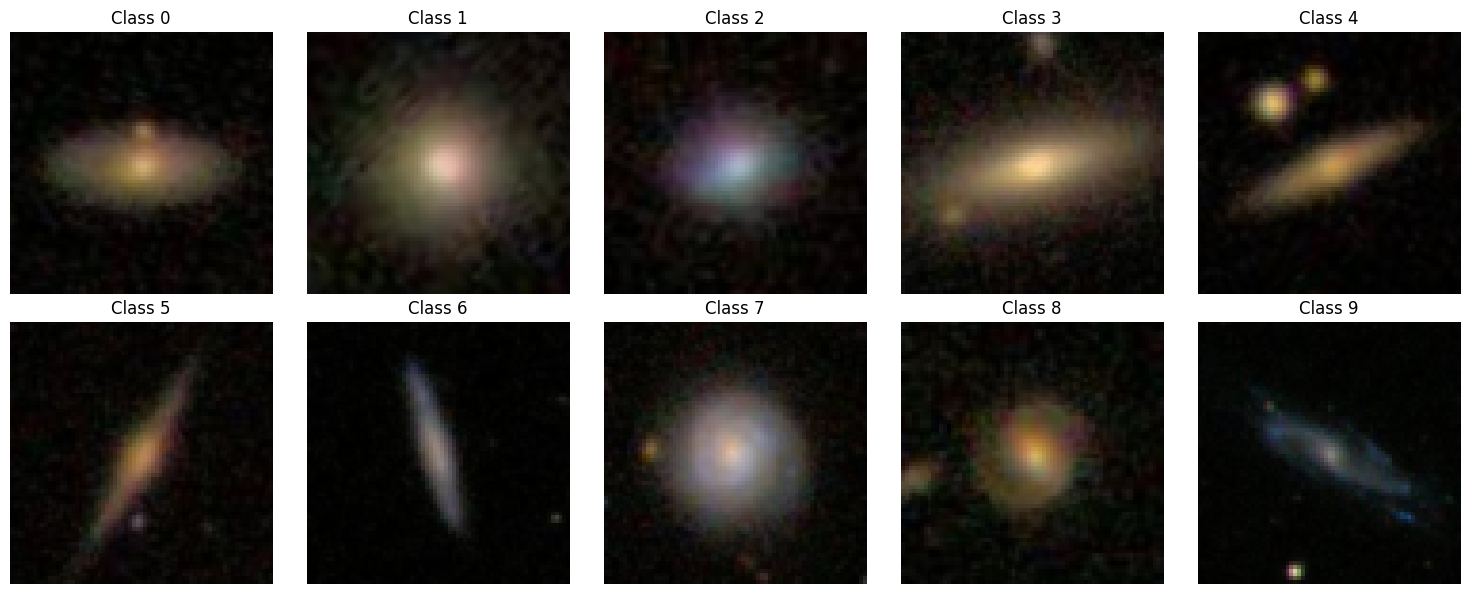

In [6]:
example_images = []
example_labels = []

for c in range(NUM_CLASSES):
    # Find first index in training set with label c
    idx = np.where(y_train == c)[0][0]
    example_images.append(X_train[idx])
    example_labels.append(c)

# Plot in 2 rows x 5 columns
fig, axes = plt.subplots(2, 5, figsize=(15,6))
for i, ax in enumerate(axes.flat):
    ax.imshow(example_images[i])
    ax.set_title(f"Class {example_labels[i]}")
    ax.axis("off")

plt.tight_layout()
plt.show()

---

## Objective 1
## Build a ten-label classifier able to distinguish the galaxies, and evaluate its performance using the most appropriate evaluation metrics 

In [7]:
cnn_model = tf.keras.Sequential([
    # Input layer
    tf.keras.layers.Input(shape=(69, 69, 3)),

    # First convolutional block
    tf.keras.layers.Conv2D(32, (5,5), padding='same', kernel_initializer='he_normal', use_bias=True),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(32, (3,3), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.15),

    # Second convolutional block
    tf.keras.layers.Conv2D(64, (5,5), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.2),

    # Third convolutional block 
    tf.keras.layers.Conv2D(128, (5,5), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.Conv2D(128, (3,3), padding='same', kernel_initializer='he_normal'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation("relu"),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    # Global pooling and dense layers
    tf.keras.layers.GlobalAveragePooling2D(),
    #tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

2026-04-16 14:01:00.395612: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### CNN model architecture

#### Neural Networks

A Neural Network maps an input image to an output prediction through stacked layers.

A generic layer block is:
$$z = Wx + b,\quad a = \phi(z)$$
where $z$ is the linear transformation, $\phi$ is the activation function, and stacking these blocks builds the full network.

1. Forward pass: the input is propagated through the layers to produce a prediction.
2. Loss computation: the prediction is compared with the true label to measure error.
3. Backpropagation: gradients are computed and weights are updated to reduce the error.


The gradient is the learning signal: it tells each weight in which direction and by how much it should move to improve predictions.

$$W \leftarrow W - \eta \frac{\partial L}{\partial W}$$

Where:
- $W$: model parameters
- $L$: training error (loss)
- $\frac{\partial L}{\partial W}$: gradient of loss with respect to parameters
- $\eta$: learning rate

The minus sign means we move parameters in the direction that reduces loss.

#### Convolutional Neural Network (CNN)

A **Convolutional Neural Network (CNN)** is a deep learning architecture specifically designed to process grid-like data, like images. Unlike fully connected neural networks where every neuron connects to every neuron in the previous layer, CNNs use localized connections and feature reuse to reduce parameters while improving performance.

A convolution slides a small learnable filter (kernel) across an image, computing dot products at each position:

$$\text{Output}[i,j] = \sum_{m=0}^{k-1} \sum_{n=0}^{k-1} \text{Kernel}[m,n] \cdot \text{Input}[i+m, j+n] + \text{bias}$$

Convolution is ideal for images because:
- **Local connectivity**: pixels are most correlated with nearby pixels
- **Parameter sharing**: same kernel detects the same pattern anywhere (translation invariance)
- **Hierarchical structure**: from low-level patterns -> high-level features


#### Chosen Architecture

The model processes images in two phases:
1. **Convolutional blocks**: extract hierarchical spatial features from the raw pixel values (edges, textures, shapes, galaxy structures).
2. **Fully connected layers**: combine all extracted features globally to produce a final class prediction.

A **fully connected** (Dense) layer connects every input value to every neuron — unlike convolutional layers which only look at a local spatial patch. After flattening, the spatial structure is gone and the network needs to learn arbitrary combinations of all detected features across the whole image. This global reasoning is what enables the final classification decision.

- **Input Layer**
  
  Each input image is 69 pixels x 69 pixels x 3 color channels (g, r, i SDSS bands) normalized to [0,1] range. This represents galaxy images from the Sloan Digital Sky Survey across three photometric bands.

- **Convolutional Blocks ($\times 3$)**

  Each block follows the same pattern, progressively learning more complex features: block 1: 32 filters -> block 2: 64 filters -> block 3: 128 filters

  Within each block:

  1. **Conv2D(kernel_size=(5,5))** 
    
      Slides a 5x5 filter n times (n=32, 64, 128 for blocks 1, 2, 3) across the image to capture broad galaxy features.
      Each filter is a small matrix of weights that learns to detect specific patterns by computing dot products with overlapping image patches.
      Output: n feature maps (one per filter), each of size 69×69, where each pixel represents activation strength for that feature.
      Padding effect (here: same padding): zeros are added at the borders so edge pixels are processed as often as central pixels, and spatial size is preserved after convolution.
      Early layers capture simpler patterns with fewer filters, while deeper layers combine them into more complex features, so filter count increases across blocks.

  2. **BatchNormalization**
    
      Normalizes layer outputs to have mean 0 and standard deviation 1 across each minibatch. This stabilizes the learning process.
      
        - During training, early layers keep changing, so the input distribution seen by deeper layers shifts. Normalization reduces this shift, so deeper layers can focus on learning useful patterns.
        - Each minibatch has slightly different statistics, introducing small noise that acts as regularization and improves robustness across batches.
        - With class imbalance, minority-class signals are weaker. Stable activations help gradients propagate more reliably, which supports learning on rare classes.

  3. **ReLU Activation**
    
      Activation function: mathematical operation applied to layer outputs. Introduces non-linearity, allowing the network to learn more complex patterns.

      **ReLU (Rectified Linear Unit)**: $\text{ReLU}(x) = \max(0, x)$ -> passes positive values unchanged and sets all negative inputs to zero

        - Without activation functions, stacked layers collapse into one linear map: if $h_1=W_1x+b_1$ and $h_2=W_2h_1+b_2$, then $h_2=(W_2W_1)x+(W_2b_1+b_2)$, still linear in $x$. ReLU breaks this linearity, enabling complex decision boundaries.
        - ReLU uses a simple threshold operation, so it is computationally cheap.
        - In deep networks, gradients can become very small as they pass backward through many layers (vanishing gradient). When this happens, early layers almost stop learning. ReLU helps because for positive inputs its derivative is 1, so the learning signal stays stronger across layers.

    
  4. **Conv2D(kernel_size=(3,3))**
      
      Slides a 3x3 filter n times (n=32, 64, 128 for blocks 1, 2, 3) across the image to refine broad galaxy features and capture finer details.
      Combination of 5x5 and 3x3 kernels enables multi-scale feature extraction: larger kernel captures broad structure, smaller kernel captures local details.

  5. **BatchNormalization**
      
  6. **ReLU Activation**
      
  7. **MaxPooling2D((2,2))**
      
      Downsamples by taking the maximum value in each 2x2 window (stride 2, no padding).
      With no padding, border leftovers are dropped when the size is odd -> no injection of artificial borders values ->dimensions are reduced by floor division.
      Spatial dimensions across blocks: block 1: 69×69 -> 34×34, block 2: 34×34 -> 17×17, block 3: 17×17 -> 8×8
    
      - Reduces parameters and computation
      - Provides small translation robustness (small shifts don't change max values significantly)
      - Keeps strongest local responses (most discriminative signals)

  8. **Dropout**
    
      Randomly deactivates 15%, 20%, 25% of neurons during training (first, second, third block respectively).
      During training, with probability p (0.15/0.20/0.25), each neuron output is set to zero and not updated. At test time, all neurons are active and outputs are scaled by (1-p) to maintain expected values.
        - Prevents co-adaptation: neurons can't rely on specific partners being active
        - Forces network to learn redundant, robust features
        - Percentage increases in deeper blocks (deeper layers overfit more easily)
        - Acts as ensemble training: each forward pass uses different random network sub-architecture

- **GlobalAveragePooling2D**
  
  It computes the spatial mean of each 128 feature maps, producing a 128 dimensional vector. This reduces the number of parameters entering the dense layer, acts as a regularizer and mekes the network robust to small translations.
  
  Previoulsy tried "Flatten": convert spatial feature maps (8x8x128 = 8192 values) into 1D vector.  Necessary to provide flat input to fully connected layers. With GlobalAveragePooling2d the positional sensitivity that there was with Flatten caused by off-centered galaxies is eliminated.

- **Dense(256, ReLU)**
  
  Fully connected layer with 256 neurons that combines all learned features into the final decision space. Input: 128-dimensional vector -> 256-dimensional representation (128*256+256=33024 trainabe weights).
  Each neuron computes a weighted sum over the entire input vector followed by a bias and ReLU  activation compressing the feature vector into a representation before classification.

- **Dropout(0.5)**
  
  Heavy regularization on the fully connected representation: at each training step, each Dense(256, ReLU) activation is independently masked with probability $p=0.5$.
  This means the network cannot rely on specific high-level neurons always being present.
    - Reduces overfitting in the highest-capacity part of the network
    - Encourages distributed feature representations instead of fragile single-neuron shortcuts
    - Improves generalization on unseen galaxies by making decision rules more robust

- **Dense(10, Softmax)**
 
  Final classification layer: maps the learned high-level 256 1D vector representation to 10 non-normalized class scores (logits), one per galaxy class (256 * 10 + 10 = 2570 weights). Softmax then converts these 10 logits into 10 probabilities -> 1D vector where each entry is the model confidence fot that galaxy class. Softmax activation:
  $$p_i = \frac{e^{s_i}}{\sum_{j=1}^{10} e^{s_j}}$$
  where $s_i$ is the logit for class $i$ and $p_i$ is the predicted probability.
    - Produces a valid probability distribution: $p_i \in [0,1]$ and $\sum_i p_i = 1$
    - Converts raw scores into comparable class confidences
    - Final predicted label is obtained with $\arg\max_i\, p_i$


### Compile choices: optimizer and loss (theory)

Training updates parameters through gradient descent:
$$W \leftarrow W - \eta \frac{\partial L}{\partial W}$$
At compile time we must choose:
1. **How prediction error is measured** -> loss function
2. **How gradients are converted into parameter updates** -> optimizer

#### Loss choice: Categorical Cross-Entropy

At each training step two vectors are compared:
- The true label vector encoded as a one-hot target vector:
$$\mathbf{y} = (y_1,\dots,y_{10}),\quad y_k=1\ \text{for the true class, and } y_i=0\ \text{otherwise}$$
- The output of the Dense(10, Softmax) layer, a 10-value 1D vector where each entry $p_i$ is the predicted probability for class $i$

Categorical cross-entropy $L_{CE}$ measures how far the predicted distribution $\mathbf{p}$ is from the target distribution $\mathbf{y}$:
$$L_{CE} = -\sum_{i=1}^{10} y_i \log(p_i)$$

Since $\mathbf{y}$ is one-hot, this becomes $L_{CE} = -\log(p_k)$ where $k$ is the true class.
- If the model is confident and correct ($p_k \to 1$), loss goes to 0.
- If the model is confident and wrong ($p_k \to 0$), loss becomes very large.

This is the standard multi-class choice because it has a probabilistic interpretation and gives stable gradients with softmax:
$$\frac{\partial L}{\partial s_i} = p_i - y_i$$

#### Optimizer choice: ADAM

The optimizer determines how the model updates its weights after each minibatch using the gradients computed during backpropagation. **Adam** (**Adaptive Moment Estimation**) optimizer is used for this CNN. It is a widely used optimization algorithm in deep learning because it combines:
- fast convergence
- adaptive learning rates
- robustness to noisy gradients

Instead of directly applying the raw gradient as in standard gradient descent,

$$
\theta \leftarrow \theta - \eta \nabla_\theta L
$$

where $\theta$ denote the set of all trainable parameters of the CNN.

Adam maintains two moving averages for each parameter.

The coefficients $\beta_1$ and $\beta_2$ are **Adam hyperparameters** that control the exponential moving averages used during optimization:

- $\beta_1$ controls how much past gradients influence the current update direction
- $\beta_2$ controls how much past squared gradients influence the adaptive scaling of the step size

In this implementation they are not explicitly set, so TensorFlow uses the default values:

- $\beta_1 = 0.9$
- $\beta_2 = 0.999$

These defaults are standard and generally work well for CNN training.

1. First moment: mean of gradients -> tracks the **average update direction**:

    $$
    m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t
    $$

2. Second moment: mean of squared gradients -> tracks the typical gradient magnitude:

    $$
    v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2
    $$

Since both moving averages start from zero, Adam applies bias correction during the first training steps:

$$
\hat m_t = \frac{m_t}{1-\beta_1^t}
$$

$$
\hat v_t = \frac{v_t}{1-\beta_2^t}
$$

This makes the estimates more accurate early in training.


The final parameter update is:

$$
\theta_{t+1} = \theta_t - \eta \frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
$$

where:

- $\eta$ is the learning rate
- $\epsilon$ is a small constant for numerical stability

#### Learning rate

The learning rate $\eta$ controls update the step size of each param update. Too large -> overshooting and instability, too small -> very slow learning. I set initial learning rate to $1e-4$. During training, `ReduceLROnPlateu` monitors the validation loss and multiplies the learning rate by 0.3 whenever no iprovements is seen for 4 consecutive epochs (down to a minimum of $1e-6$). The result is aggressive early progress and fine grained convergence later.

#### Regularization techniques

Regularization reduces overfitting (good train performance but poor generalization).

- **Dropout**: randomly masks activations during training.
- **Early Stopping**: stops training when validation loss no longer improves.
- **Learning-rate reduction on plateau**: improves late-stage stability and often helps generalization.
- **Batch Normalization**: mainly optimization stabilization, with a mild regularization effect from minibatch noise.

In [8]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

"""
from_logits=False informs the loss function that the output values generated by the model are probabilities, not logits. Softmax activation is already applied in the last layer, so the model outputs probabilities directly. If from_logits were set to True, it would indicate that the model outputs raw logits, and the loss function would internally apply softmax to convert them into probabilities before calculating the loss.
"""

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 69, 69, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 69, 69, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 69, 69, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 69, 69, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 69, 69, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 69, 69, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 34, 34, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 34, 34, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 17, 17, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 17, 17, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 17, 17, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 17, 17, 128)    │             

 Total params: 489,770 (1.87 MB)

 Trainable params: 488,874 (1.86 MB)

 Non-trainable params: 896 (3.50 KB)

### Data augmentation and class weighting

The dataset is strongly imbalanced (some classes have many samples, others have very few).
If we train without correction, the model tends to optimize mostly for majority classes and can ignore minority classes.

#### Data augmentation

Data augmention creates additional training examples from existing images using transformations for selected classes.

Only rotations and flips are used (no colour jitter, zoom, or elastic distortions) to avoid introducing visual artefacts that could mislead the model about the physical appearance of the galaxies. Geometric transformations are morphology-preserving, making them safe for astronomical image data.

- Increases the effective size of minority-class training data
- Exposes the model to more visual variability of the same class
- Reduces overfitting to the few original minority samples
- Improves generalization on rare classes

#### Class weighting

Class weighting modifies the loss so mistakes on rare classes are penalized more than mistakes on frequent classes.

This pushes the optimizer to pay attention to minority classes instead of only maximizing majority-class accuracy.

In [ ]:
def augment_galaxy_rot_flips(X, y, class_aug_config):
    X_aug = []
    y_aug = []

    for c in np.unique(y):
        X_c = X[y==c]
        config = class_aug_config.get(c, {})

        for img in X_c:
            aug_imgs = [img.copy()]

            # Rotations
            if config.get('rotations', False):
                num_rotations = config.get('num_rotations', 0)
                if num_rotations > 0:
                    temp = []
                    for im in aug_imgs:
                        rot_options = [np.rot90(im, k=k) for k in range(1, 4)]
                        selected_rotations = random.sample(rot_options, k=min(num_rotations, len(rot_options)))
                        temp.extend(selected_rotations)
                    aug_imgs.extend(temp)

            # Flips
            if config.get('flips', False):
                num_flips = config.get('num_flips', 0)
                if num_flips > 0:
                    temp = []
                    for im in aug_imgs:
                        flip_options = [np.fliplr(im), np.flipud(im), np.flipud(np.fliplr(im))]
                        selected_flips = random.sample(flip_options, k=min(num_flips, len(flip_options)))
                        temp.extend(selected_flips)
                    aug_imgs.extend(temp)

            X_aug.extend(aug_imgs)
            y_aug.extend([c]*len(aug_imgs))

    X_aug = np.array(X_aug, dtype=np.float32)
    y_aug = np.array(y_aug, dtype=np.int32)
    return X_aug, y_aug

# Per-class augmentation policy (conservative: rotations/flips only)
class_aug_config = {
    0: {'rotations': False, 'flips': False}, 
    1: {'rotations': False, 'flips': False}, 
    2: {'rotations': False, 'flips': False}, 
    3: {'rotations': False, 'flips': True, 'num_flips': 3},
    4: {'rotations': False, 'flips': False}, 
    5: {'rotations': True,  'num_rotations': 3, 'flips': True, 'num_flips': 3},
    6: {'rotations': False, 'flips': False}, 
    7: {'rotations': False, 'flips': True,  'num_flips': 1}, 
    8: {'rotations': False, 'flips': True,  'num_flips': 1}, 
    9: {'rotations': False, 'flips': True,  'num_flips': 1}, 
}

X_train_aug, y_train_aug = augment_galaxy_rot_flips(X_train, y_train, class_aug_config)

classes = np.unique(y_train)
print("Augmentation effect:")

for c in classes:
    n_before = np.sum(y_train == c)
    n_after = np.sum(y_train_aug == c)
    print(f"Class {c}: {n_before} images before -> {n_after} images after")

print(f"\nTotal images: {len(y_train)} before -> {len(y_train_aug)} after")

Augmentation effect:
Class 0: 2423 images before -> 2423 images after
Class 1: 4898 images before -> 4898 images after
Class 2: 4404 images before -> 4404 images after
Class 3: 244 images before -> 244 images after
Class 4: 1074 images before -> 1074 images after
Class 5: 12 images before -> 192 images after
Class 6: 412 images before -> 412 images after
Class 7: 785 images before -> 1570 images after
Class 8: 634 images before -> 1268 images after
Class 9: 363 images before -> 726 images after

Total images: 15249 before -> 17211 after


In [10]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train_aug)  # class labels present after augmentation
class_weights = compute_class_weight(
    class_weight='balanced',   # inverse-frequency weighting
    classes=classes,           # list of class ids to weight
    y=y_train_aug              # training labels used to estimate frequencies
)

class_weight_dict = dict(zip(classes, class_weights))  
print(class_weight_dict)

{np.int32(0): np.float64(0.7103177878662814), np.int32(1): np.float64(0.3513883217639853), np.int32(2): np.float64(0.39080381471389647), np.int32(3): np.float64(7.053688524590164), np.int32(4): np.float64(1.6025139664804469), np.int32(5): np.float64(8.9640625), np.int32(6): np.float64(4.177427184466019), np.int32(7): np.float64(1.0962420382165605), np.int32(8): np.float64(1.3573343848580441), np.int32(9): np.float64(2.3706611570247933)}


In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',        # watch validation loss
    patience=12,                # stop after 12 epochs without improvement
    restore_best_weights=True, # use the model from the best epoch
    verbose=1                  # print message when stopping
)

In [12]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor="val_loss",  # watch validation loss
    factor=0.3,         # new_lr = old_lr * 0.3 when plateau is detected
    patience=4,         # wait 4 epochs without improvement before reducing LR
    min_lr=1e-6,        # do not reduce below this minimum learning rate
    verbose=1           # print a message when LR is reduced
)

In [13]:
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    precision_recall_fscore_support
)

class ValidationMetricsCallback(tf.keras.callbacks.Callback):
    def __init__(self, val_data):
        super().__init__()
        self.x_val, self.y_val = val_data

        self.macro_f1 = []
        self.balanced_acc = []
        self.per_class_metrics = []

    def on_epoch_end(self, epoch, logs=None):
        y_true = np.argmax(self.y_val, axis=1)
        y_pred = np.argmax(self.model.predict(self.x_val, verbose=0), axis=1)

        # Macro-F1: average F1 across classes (all classes weighted equally).
        macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
        # Balanced accuracy: average recall across classes (robust to imbalance).
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        self.macro_f1.append(macro_f1)
        self.balanced_acc.append(bal_acc)

        # Per-class precision, recall, F1, and support (number of true samples).
        precision, recall, f1, support = precision_recall_fscore_support(
            y_true, y_pred, zero_division=0
        )

        self.per_class_metrics.append({
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support
        })

        print(
            f"\nEpoch {epoch+1}: "
            f"Macro-F1={macro_f1:.3f}, "
            f"Balanced Acc={bal_acc:.3f}"
        )


In [14]:
# If a saved trained model already exists at `../artifacts/galaxy_cnn.keras` and `FORCE_RETRAIN = False`,
# the training cell will skip fit() and load that model.
# Set environment variable `FORCE_RETRAIN=1` to force a fresh fit and overwrite the saved model.

MODEL_DIR = "../artifacts"
MODEL_PATH = os.path.join(MODEL_DIR, "galaxy_cnn.keras")
FORCE_RETRAIN = os.getenv("FORCE_RETRAIN", "0") == "1"
os.makedirs(MODEL_DIR, exist_ok=True)

def ensure_trained_model_loaded():
    global cnn_model
    if "cnn_model" not in globals():
        if not os.path.exists(MODEL_PATH):
            raise RuntimeError("No trained model found. Run the training cell once to create and save the model")
        cnn_model = tf.keras.models.load_model(MODEL_PATH)
        print(f"Loaded trained model from {MODEL_PATH}")
    return cnn_model

def should_skip_training():
    return os.path.exists(MODEL_PATH) and not FORCE_RETRAIN

print(f"Model checkpoint path: {MODEL_PATH}")
print(f"FORCE_RETRAIN={FORCE_RETRAIN} (set env FORCE_RETRAIN=1 to force fit())")
if should_skip_training():
    print(f"Saved trained model found at {MODEL_PATH}. The training cell will load it and skip fit().")
else:
    print("No saved trained model found (or retraining was forced). The training cell will run fit().")

Model checkpoint path: ../artifacts/galaxy_cnn.keras
FORCE_RETRAIN=False (set env FORCE_RETRAIN=1 to force fit())
Saved trained model found at ../artifacts/galaxy_cnn.keras. The training cell will load it and skip fit().


In [15]:
# Train the model only if needed
if should_skip_training():
    cnn_model = tf.keras.models.load_model(MODEL_PATH)
    results = None
    val_metrics_cb = None
    print(f"Skipping fit(): loaded existing model from {MODEL_PATH}. Set FORCE_RETRAIN=1 to retrain.")
else:
    y_train_aug_oh = tf.keras.utils.to_categorical(y_train_aug, NUM_CLASSES)
    y_val_oh = tf.keras.utils.to_categorical(y_val, NUM_CLASSES)

    val_metrics_cb = ValidationMetricsCallback(
        val_data=(X_val, y_val_oh)
    )

    # Epoch = one full pass over the training set
    # Batch = number of samples per gradient update
    EPOCHS = 75
    BATCH_SIZE = 64

    results = cnn_model.fit(
        X_train_aug, y_train_aug_oh,                 # training inputs and one-hot labels
        epochs=EPOCHS,                               # maximum number of full passes over training data
        batch_size=BATCH_SIZE,                       # mini-batch size used for each weight update
        validation_data=(X_val, y_val_oh),           # validation set evaluated at the end of each epoch
        shuffle=True,                                # reshuffle training samples every epoch
        class_weight=class_weight_dict,              # higher loss weight for underrepresented classes
        callbacks=[                                  # training control hooks executed during fit
            val_metrics_cb,                          # custom imbalance-aware validation metrics
            early_stopping,                          # stop when val_loss stops improving
            lr_scheduler                             # reduce learning rate on val_loss plateau
        ]
    )

    cnn_model.save(MODEL_PATH)
    print(f"Saved trained model to {MODEL_PATH}")

Skipping fit(): loaded existing model from ../artifacts/galaxy_cnn.keras. Set FORCE_RETRAIN=1 to retrain.


### Per-epoch metrics used in this notebook

At each epoch (one full pass over the training set), training and validation metrics monitoring

1. Accuracy (`accuracy`, `val_accuracy`)
    - Definition: fraction of correctly classified samples
    - Formula: `Accuracy = (number of correct predictions) / (total samples)`
    - @ith strong class imbalance, accuracy can look high even if minority classes are poorly predicted.

2. Loss (`loss`, `val_loss`)
    - Definition: optimization objective minimized during training
    - Lower is better.
    - `loss` tracks fit on training batches
    - `val_loss` tracks generalization on unseen validation data.

3. Per-class precision, recall, and F1 (multiclass, one-vs-rest)
    For each class `c`:
    - `TP_c`: true label is `c` and predicted label is `c` (True Positive)
    - `FN_c`: true label is `c` but predicted label is not `c` (True Negative)
    - `FP_c`: true label is not `c` but predicted label is `c` (False Positive)

    From these counts:
    - `Precision_c = TP_c / (TP_c + FP_c)`
      - Among predictions of class `c`, how many are correct
    - `Recall_c = TP_c / (TP_c + FN_c)`
      - Among true samples of class `c`, how many are correctly found
    - `F1_c = 2 * Precision_c * Recall_c / (Precision_c + Recall_c)`
      - HArmonic mean of predictiona nd recall -> high only when both precision and recall are high

4. Macro-F1 (`macro_f1`)
    - Definition: arithmetic mean of `F1_c` across classes
    - Formula: `Macro-F1 = mean_c(F1_c)`.
    - Equal weight to each class -> minority classes are not overshadowed by majority classes

5. Balanced Accuracy (`balanced_acc`)
    - Definition: arithmetic mean of per-class recall
    - Formula: `Balanced Accuracy = mean_c(Recall_c)`
    - Measures class-wise recovery quality and is robust to imbalance

Using training history from: saved_file (../artifacts/train_once_history.json)


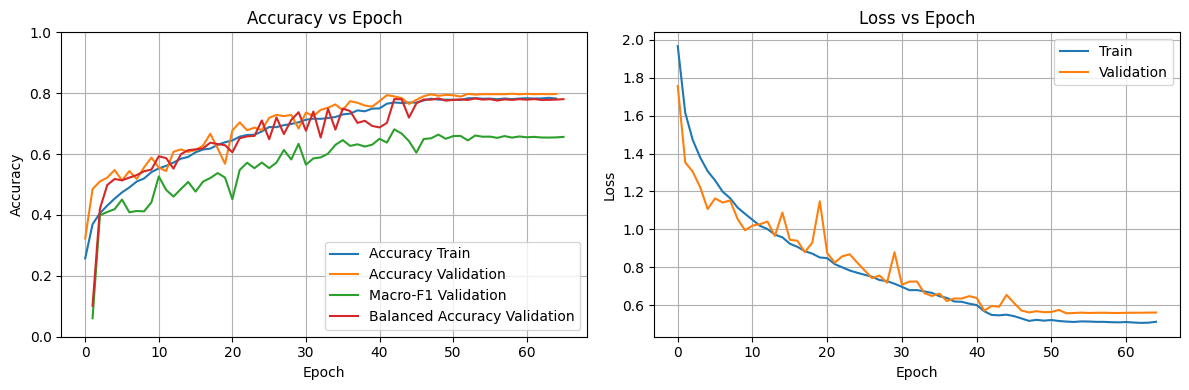

In [16]:
# Plot training history
# If training was skipped in this session, load history saved by train_once.py
history_source = None
loaded_history = None
loaded_macro_f1 = None
loaded_balanced_acc = None
history_path = "../artifacts/train_once_history.json"

if results is not None and val_metrics_cb is not None:
    import json

    history_source = "current_session"
    loaded_history = dict(results.history)
    loaded_macro_f1 = list(val_metrics_cb.macro_f1)
    loaded_balanced_acc = list(val_metrics_cb.balanced_acc)

    # Compute/fill missing custom metrics from callback and save for future sessions
    if "macro_f1" not in loaded_history:
        loaded_history["macro_f1"] = [float(x) for x in loaded_macro_f1]
    if "balanced_acc" not in loaded_history:
        loaded_history["balanced_acc"] = [float(x) for x in loaded_balanced_acc]

    with open(history_path, "w", encoding="utf-8") as f:
        json.dump(loaded_history, f, indent=2)
    print(f"Saved training history (including custom metrics) to {history_path}")
else:
    if os.path.exists(history_path):
        import json
        with open(history_path, "r", encoding="utf-8") as f:
            loaded_history = json.load(f)
        history_source = f"saved_file ({history_path})"

        loaded_macro_f1 = loaded_history.get("macro_f1")
        loaded_balanced_acc = loaded_history.get("balanced_acc")
    else:
        print("Training was skipped and no saved history file was found.")
        print("Expected file:", history_path)
        print("Run train_once.py once to create train_once_history.json, then rerun this cell.")

if loaded_history is not None:
    print(f"Using training history from: {history_source}")

    plt.figure(figsize=(12, 4))

    # Left panel: accuracy-style metrics
    plt.subplot(1, 2, 1)
    if "accuracy" in loaded_history:
        # Training accuracy
        plt.plot(loaded_history["accuracy"], label="Accuracy Train")
    if "val_accuracy" in loaded_history:
        # Validation accuracy
        plt.plot(loaded_history["val_accuracy"], label="Accuracy Validation")

    if loaded_macro_f1 is not None:
        # Macro-F1
        epochs = range(1, len(loaded_macro_f1) + 1)
        plt.plot(epochs, loaded_macro_f1, label="Macro-F1 Validation")
    if loaded_balanced_acc is not None:
        # Balanced accuracy
        epochs = range(1, len(loaded_balanced_acc) + 1)
        plt.plot(epochs, loaded_balanced_acc, label="Balanced Accuracy Validation")

    ax = plt.gca()
    ax.set_ylim([0, 1])
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True)
    plt.legend()
    plt.title("Accuracy vs Epoch")

    # Right panel: loss metrics 
    plt.subplot(1, 2, 2)
    if "loss" in loaded_history:
        # Training loss
        plt.plot(loaded_history["loss"], label="Train")
    if "val_loss" in loaded_history:
        # Validation loss
        plt.plot(loaded_history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.title("Loss vs Epoch")

    plt.tight_layout()
    plt.show()

    """
    # Print available series for transparency
    for k in ["accuracy", "val_accuracy", "loss", "val_loss"]:
        if k in loaded_history:
            print(f"{k} =", loaded_history[k])
    if loaded_macro_f1 is not None:
        print("macro_f1 =", loaded_macro_f1)
    if loaded_balanced_acc is not None:
        print("balanced_acc =", loaded_balanced_acc)
    """

In [17]:
import json

# Show per-class validation metrics from the current session if available;
# otherwise load the last saved epoch from train_once_history.json.
history_path = "../artifacts/train_once_history.json"
final = None
source = None

if val_metrics_cb is not None and len(val_metrics_cb.per_class_metrics) > 0:
    final = val_metrics_cb.per_class_metrics[-1]
    source = "current session"
elif os.path.exists(history_path):
    with open(history_path, "r", encoding="utf-8") as f:
        saved_history = json.load(f)
    per_class_history = saved_history.get("per_class_metrics")
    if per_class_history:
        final = per_class_history[-1]
        source = f"saved file ({history_path})"

if final is None:
    print("Per-class validation metrics are not available.")
    print("Run training once (or run train_once.py) to generate and save them.")
else:
    print(f"Validation per class metrics from: {source}")
    for i in range(len(final["precision"])):
        print(
            f"Class {i:2d} | "
            f"P={float(final['precision'][i]):.2f} "
            f"R={float(final['recall'][i]):.2f} "
            f"F1={float(final['f1'][i]):.2f} "
            f"N={int(final['support'][i])}"
        )

Validation per class metrics from: saved file (../artifacts/train_once_history.json)
Class  0 | P=0.76 R=0.47 F1=0.58 N=519
Class  1 | P=0.89 R=0.94 F1=0.92 N=1049
Class  2 | P=0.86 R=0.87 F1=0.86 N=944
Class  3 | P=0.37 R=0.89 F1=0.52 N=53
Class  4 | P=0.90 R=0.71 F1=0.80 N=230
Class  5 | P=0.11 R=1.00 F1=0.19 N=2
Class  6 | P=0.79 R=0.80 F1=0.79 N=89
Class  7 | P=0.57 R=0.77 F1=0.65 N=168
Class  8 | P=0.63 R=0.60 F1=0.61 N=136
Class  9 | P=0.55 R=0.76 F1=0.64 N=78


In [18]:
# Predict class probabilities
ensure_trained_model_loaded()

y_pred_prob = cnn_model.predict(X_test)

# Convert to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


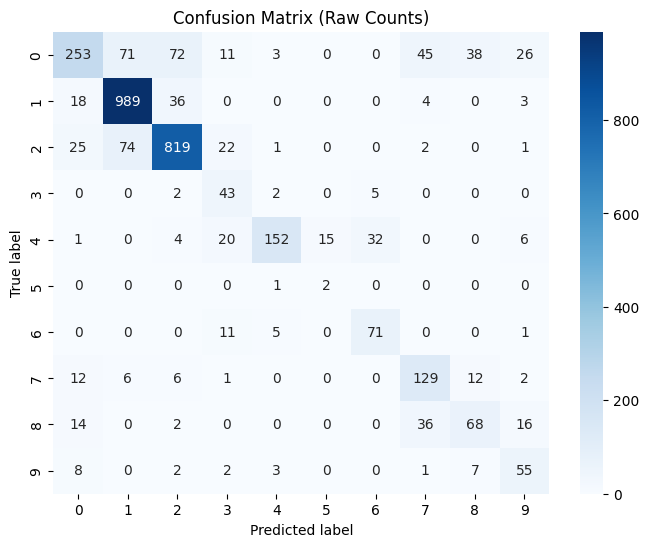

In [19]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
#print("Confusion matrix from prediction\n", cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Raw Counts)')
plt.show()

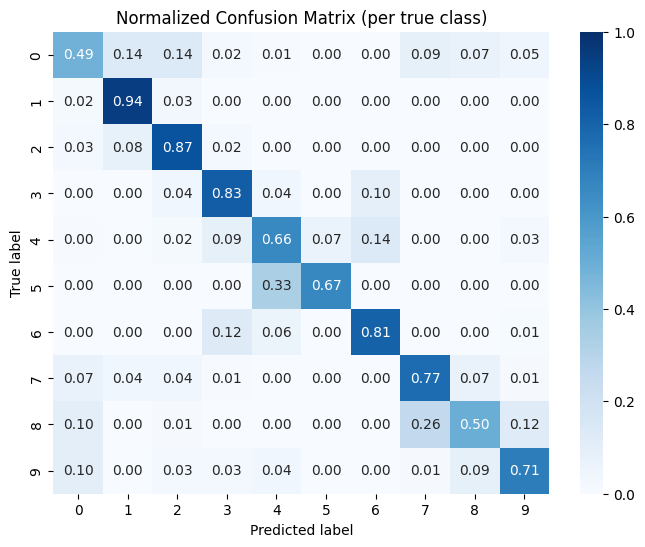

In [20]:
cm_norm = cm.astype(np.float32) / cm.sum(axis=1, keepdims=True)

# Normalized confusion matrix (per true class) - shows recall per class
# Each row is divided by the total of that true class -> each row sums to 1 -> val(i,j) is the fraction of true class i predicted as class j
# For a real class i, where did its samples go in the predictions? Recal per class

#print("Normalized Confusion Matrix (per true class)\n", cm_norm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=range(cm.shape[0]),
    yticklabels=range(cm.shape[0]),
    vmin=0,
    vmax=1
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix (per true class)")
plt.show()

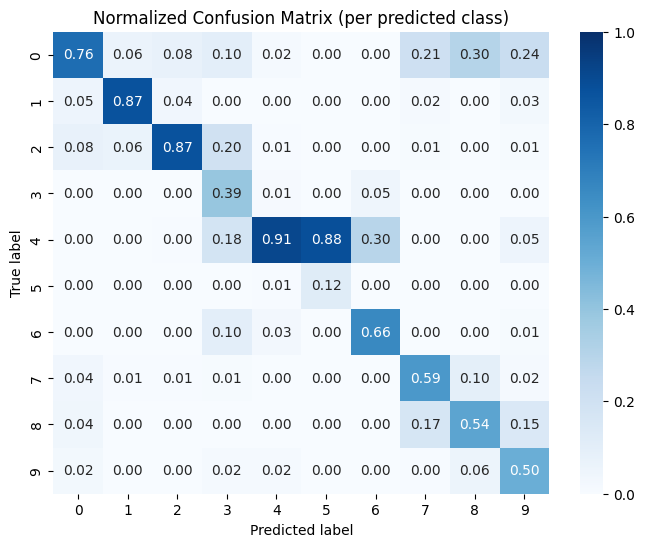

In [21]:
cm_col_norm = cm.astype(np.float32) / np.maximum(cm.sum(axis=0, keepdims=True), 1)

# Normalized confusion matrix (per predicted class) - shows precision per class
# Each column is divided by the total of that predicted class -> each column sums to 1 -> val(i,j) is the fraction of predicted class j that actually belongs to true class i
# For a predicted class j, where did its samples come from in the true labels? Precision per class

#print("Normalized Confusion Matrix (per predicted class)\n", cm_col_norm)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_col_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=range(cm.shape[0]),
    yticklabels=range(cm.shape[0]),
    vmin=0,
    vmax=1
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Normalized Confusion Matrix (per predicted class)")
plt.show()


Both normalized confusion mattrices provide a class-wise view

1. **Row-normalized matrix (per true class)**
   - Each row sums to 1 and can be read as **recall by class**
   - It answers: for a true class $i$, where did its samples go?
   - Main observations from the current output:
     - Strong recall for classes 1, 2, and 6 (high diagonal values)
     - Lower recall for class 0: many true class-0 samples are predicted as classes 1 and 2 (and partly 7, 8, 9)
     - Very low recall for class 5: most true class-5 samples are predicted as class 4
     - Class 8 shows strong confusion with classes 7 and 9

2. **Column-normalized matrix (per predicted class)**
   - Each column sums to 1 and can be read as **precision by predicted class**
   - It answers: when the model predicts class $j$, from which true classes do those predictions come?
   - Main observations from the current output:
     - Predictions for classes 1, 2, and 4 are relatively pure (high diagonal values)
     - Predicted class 5 has low purity: many samples predicted as 5 are actually class 4
     - Predicted classes 7, 8, and 9 are mixed, confirming overlap among spiral-like morphologies

**Overall conclusion**
- Best separated classes: 1, 2, 4, and 6
- Most difficult cases: class 5 and the 7-8-9 group
- Consistent with class imbalance and morphological similarity between some galaxy classes

In [22]:
# Classification report and aggregate test metrics
from sklearn.metrics import (classification_report, accuracy_score, balanced_accuracy_score, f1_score, top_k_accuracy_score)

# Aggregate metrics
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)  # Mean recall across classes
macro_f1 = f1_score(y_test, y_pred, average="macro")  # Equal weight to each class
weighted_f1 = f1_score(y_test, y_pred, average="weighted")  # Weighted by class support

# Top-k accuracy: prediction is correct if true class is in top-k probabilities
top1 = top_k_accuracy_score(y_test, y_pred_prob, k=1)
top3 = top_k_accuracy_score(y_test, y_pred_prob, k=3)
top5 = top_k_accuracy_score(y_test, y_pred_prob, k=5)

print("Overall test metrics:")
print(f"Accuracy           : {accuracy:.4f}")
print(f"Balanced accuracy  : {balanced_acc:.4f}")
print(f"Macro F1-score     : {macro_f1:.4f}")
print(f"Weighted F1-score  : {weighted_f1:.4f}")
print(f"Top-1 accuracy     : {top1:.3f}")
print(f"Top-3 accuracy     : {top3:.3f}")
print(f"Top-5 accuracy     : {top5:.3f}")

# Per-class metrics: precision, recall, F1, and support
report = classification_report(y_test, y_pred, digits=4, output_dict=True)
print("\nPer class test metrics:")
for cls, metrics in report.items():
    if cls.isdigit():
        print(
            f"Class {cls} | "
            f"P={metrics['precision']:.2f} "
            f"R={metrics['recall']:.2f} "
            f"F1={metrics['f1-score']:.2f} "
            f"N={metrics['support']}"
        )

Overall test metrics:
Accuracy           : 0.7898
Balanced accuracy  : 0.7231
Macro F1-score     : 0.6364
Weighted F1-score  : 0.7876
Top-1 accuracy     : 0.790
Top-3 accuracy     : 0.983
Top-5 accuracy     : 0.999

Per class test metrics:
Class 0 | P=0.76 R=0.49 F1=0.60 N=519.0
Class 1 | P=0.87 R=0.94 F1=0.90 N=1050.0
Class 2 | P=0.87 R=0.87 F1=0.87 N=944.0
Class 3 | P=0.39 R=0.83 F1=0.53 N=52.0
Class 4 | P=0.91 R=0.66 F1=0.77 N=230.0
Class 5 | P=0.12 R=0.67 F1=0.20 N=3.0
Class 6 | P=0.66 R=0.81 F1=0.72 N=88.0
Class 7 | P=0.59 R=0.77 F1=0.67 N=168.0
Class 8 | P=0.54 R=0.50 F1=0.52 N=136.0
Class 9 | P=0.50 R=0.71 F1=0.59 N=78.0


### Interpretation of test metrics

The model reaches Top-1 Accuracy = 0.790 on the test set, which is good for a 10-class problem with strong class imbalance. However, class-sensitive metrics are lower (Balanced Accuracy = 0.723, Macro F1 = 0.636). This gap indicates uneven performance across classes: majority/easier classes (like class 1 and 2) are learned better than minority/ambiguous ones.

Top-k scores shows that the model produces a well calibrated ranking: Top-3 = 0.983, Top-5 = 0.999, meaning the correct class is almost always among the top candidate predictions even when Top-1 is wrong.

Per-class results are consistent with the confusion matrices:
- Strong classes: 1 (F1=0.90), 2 (F1=0.87), 4 (F1=0.77), 6 (F1=0.72) had well separated morphologies and reasonable support
- Challenging classes: 5 (F1=0.53), and 8 (F1=0.53) had limited support and visually overlap with close classes.
- Spiral overlap (classes 7–8–9): frequent mutual confusion, consistent with the subtle morphological differences between tight, medium, and loose spirals.
- Class 5: F1=0.20 with only 3 test samples is statistically unreliable. No conclusion should be drawn from this class alone.

Overall, the classifier is useful and robust at candidate ranking (high Top-k), but limited by class imbalance and morphological similarity. Weighted F1=0.788, accounting for class frequency, confirm that the performance on well-populated classes is ok.

---

## Objective 2
## By considering the classifier developed in 1. implement a strategy for inspecting the content of the image for understanding the portions with more discriminant information. In particular, choose one explainability method (e.g., saliency maps, feature map visualization, Grad-CAM, or another interpretable algorithm), and use it to analyze how the model arrived at its decisions

### Grad-CAM method

Grad-CAM (Gradient-weighted Class Activatino Mapping) is chosen since the classifier is a CNN with a late convolutional layers still preserving spatial strucutre information about the image. Grad-CAM computes the gradient of the score for a chosen class with respect to the feature maps of the last convolutional layer, then spatial averages those gradients to obtain one importance weight per channel. Weighting each feature map by importance and summing prodices a 2D heatmap that can be overlaid on the original galaxy image.

Grad-CAM is computed with respect to the class model predicted (not necessary the true class) -> for wrong predictions the heatmap shows which visual feaures drove the incorrect decision.

The Grad-CAM target layer is `activation_5`: the ReLU output of the last convolutional block before the MaxPooling with spatial grid 17x17

In [42]:
import cv2

# Target the last ReLU activation rather than the raw conv output:
# post-activation maps are non-negative, which is consistent with
# the relu() we apply to the heatmap later.
last_conv_layer = None
for layer in cnn_model.layers[::-1]:
    if 'activation' in layer.name.lower():
        last_conv_layer = layer.name
        break
print(f"Grad-CAM target layer: {last_conv_layer}")


Grad-CAM target layer: activation_5


In [ ]:
def compute_gradcam(model, image, class_idx, layer_name):
    """
    model: trained keras model
    image: shape (1, H, W, C)
    class_idx: predicted class index
    layer_name: last convolutional layer name
    """

    last_conv_layer = model.get_layer(layer_name)
    last_conv_index = next(i for i, layer in enumerate(model.layers) if layer.name == layer_name)

    feature_extractor = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=last_conv_layer.output
    )

    classifier_input = tf.keras.Input(shape=last_conv_layer.output.shape[1:])
    x = classifier_input
    for layer in model.layers[last_conv_index + 1:]:
        x = layer(x, training=False) if hasattr(layer, 'training') else layer(x)

    classifier_model = tf.keras.models.Model(classifier_input, x)

    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = feature_extractor(image_tensor, training=False)
        tape.watch(conv_outputs)
        predictions = classifier_model(conv_outputs, training=False)
        loss = predictions[:, class_idx]

    # Compute how much each spatial activation in the conv maps
    # influences the score of the target class
    grads = tape.gradient(loss, conv_outputs)

    if grads is None:
        raise RuntimeError(
            "Grad-CAM gradients could not be computed for the selected layer"
        )

    # Average the gradients over height and width to obtain one importance
    # weight per channel of the convolutional output
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Remove the batch dimension: we are explaining a single image
    conv_outputs = conv_outputs[0]

    # Weight each feature-map channel by its importance and sum them
    # to produce a single 2D class-activation map
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # Keep only positive evidence for the class and normalize to [0, 1]
    # so the map can be visualized as an intensity heatmap
    heatmap = tf.nn.relu(heatmap)
    max_val = tf.reduce_max(heatmap)
    if max_val > 1e-8:
        heatmap = heatmap / max_val

    return heatmap.numpy()


In [44]:
def overlay_gradcam(image, heatmap, alpha=0.4):
    """
    image: (H, W, 3) in [0,1]
    heatmap: (h, w)
    """

    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_INFERNO)

    image_uint8 = np.uint8(255 * image)
    overlay = cv2.addWeighted(image_uint8, 1 - alpha, heatmap, alpha, 0)

    return overlay

In [45]:
def get_correct_wrong_indices(y_true, y_pred, cls, n_correct=3, n_wrong=3):
    rng = np.random.default_rng(seed=SEED)

    correct = np.where((y_true == cls) & (y_pred == cls))[0]
    wrong   = np.where((y_true == cls) & (y_pred != cls))[0]

    correct = rng.choice(correct, size=min(n_correct, len(correct)), replace=False)
    wrong   = rng.choice(wrong,   size=min(n_wrong,   len(wrong)),   replace=False)
    return correct, wrong

In [46]:
# Warmup call: forces TensorFlow to build and trace the computation graph
# before the timed gallery loop. Without this, the first predict() call
# includes graph-building overhead and can skew timing
_ = cnn_model.predict(X_test[:1], verbose=0)

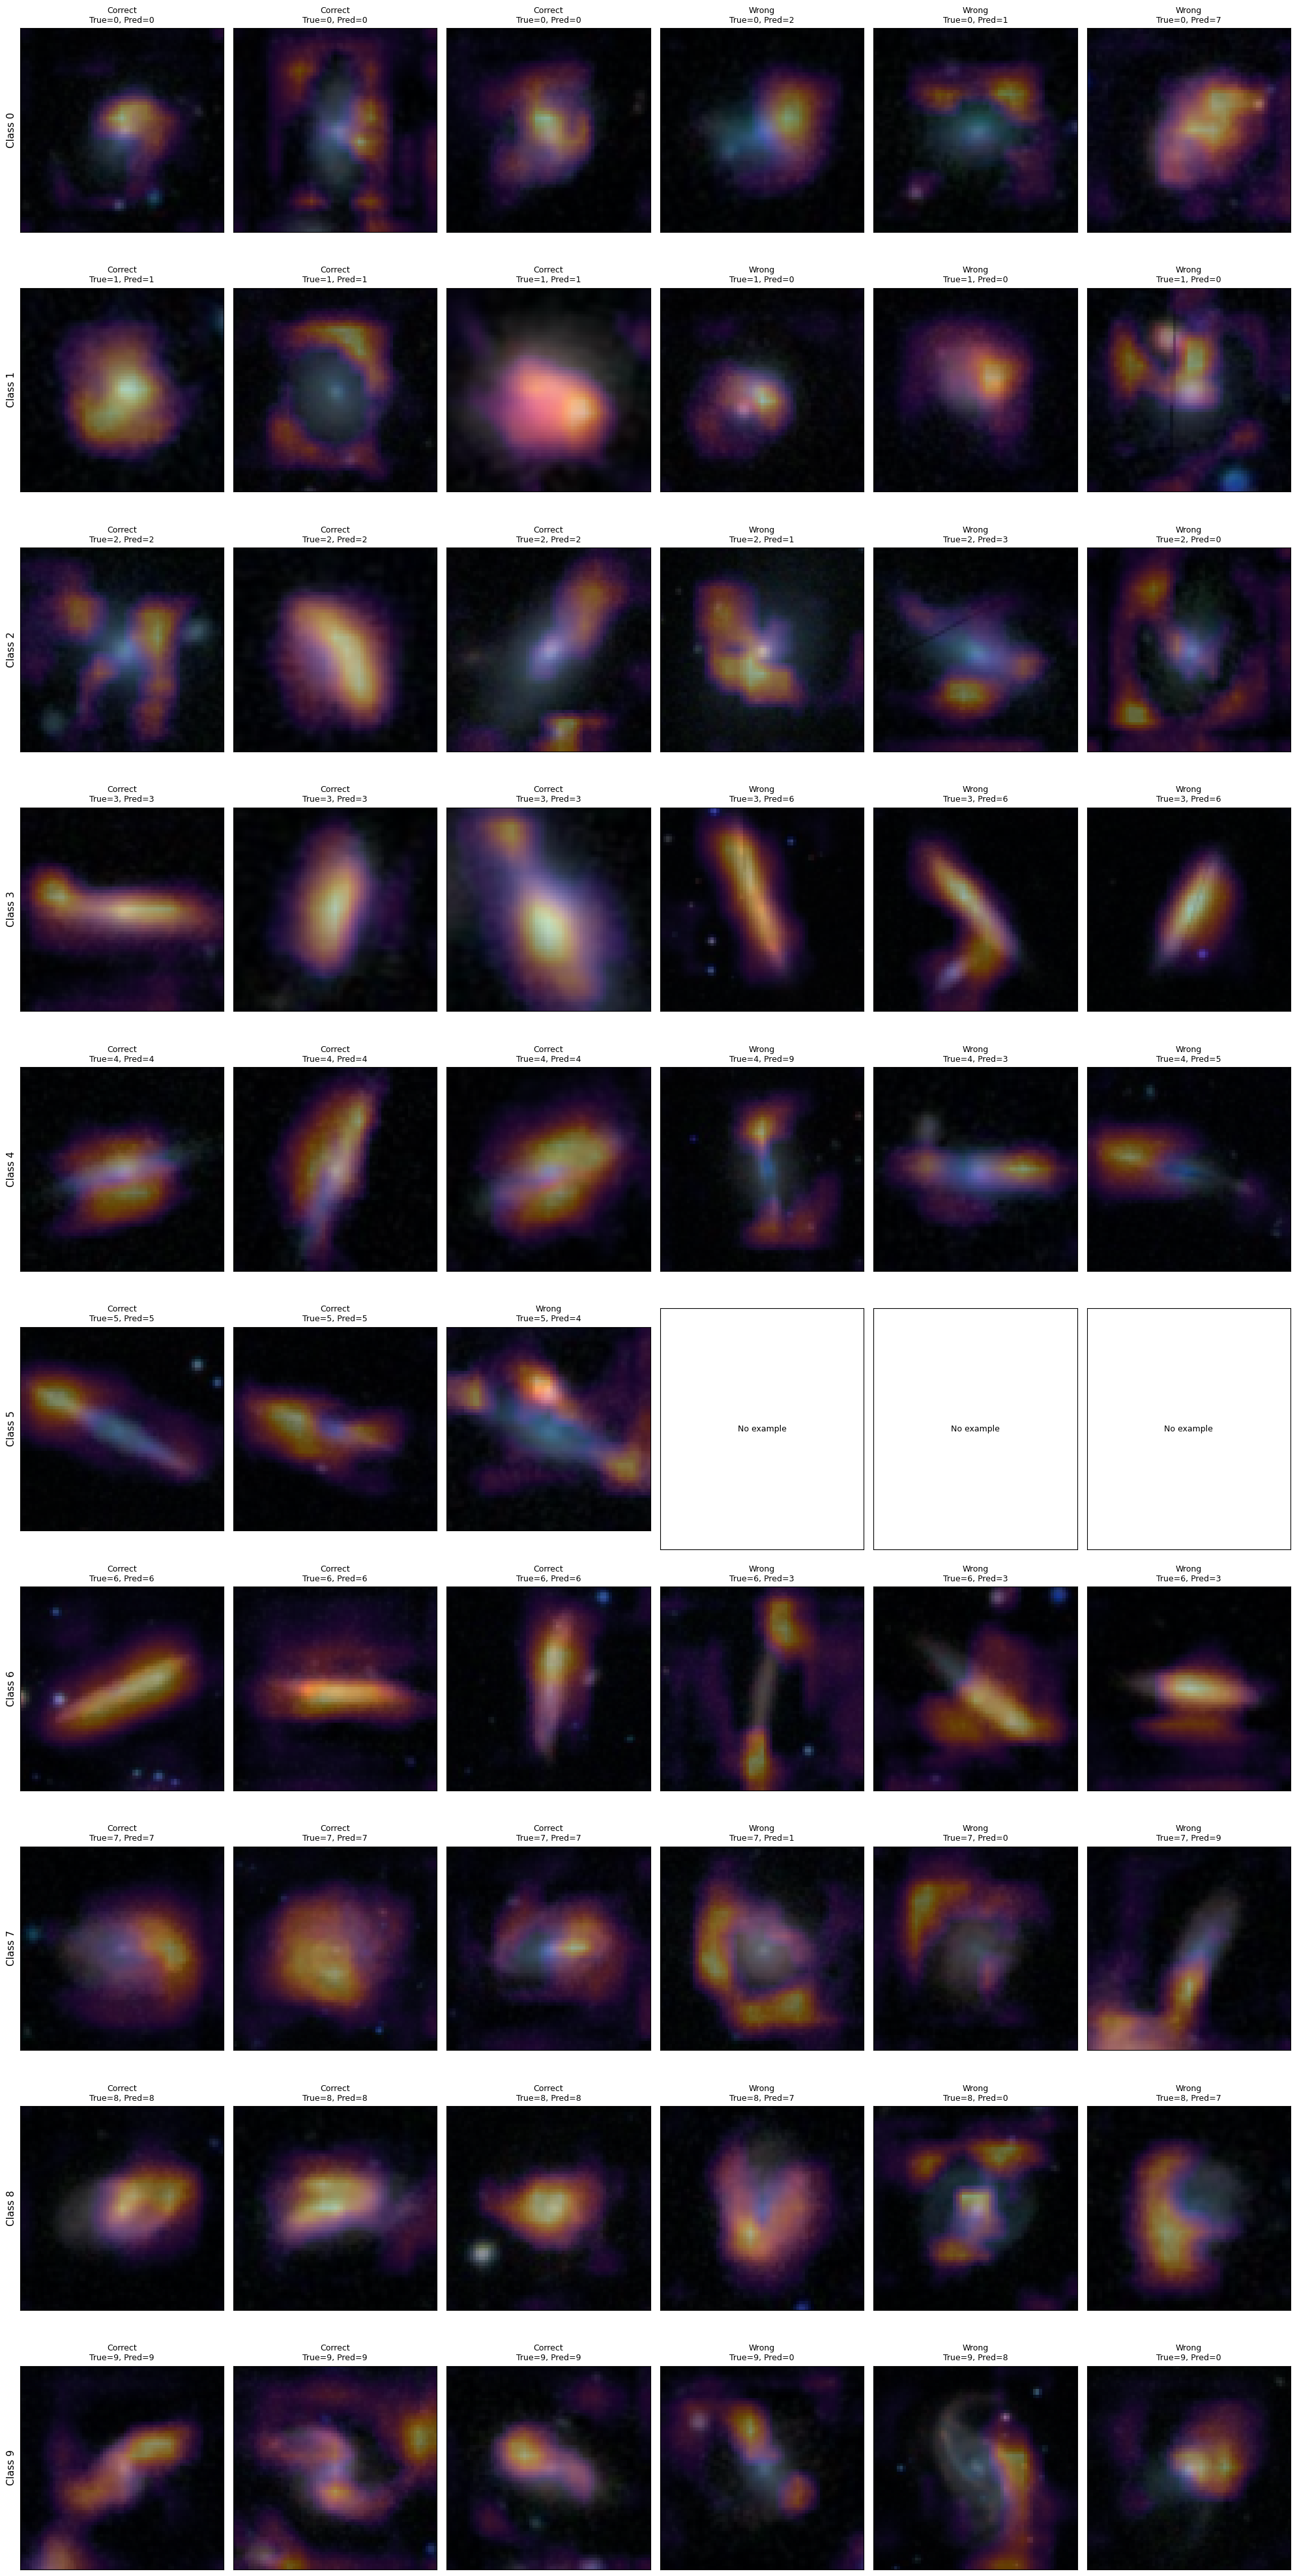

In [47]:
# Build a Grad-CAM gallery with correct and wrong predictions examples

ensure_trained_model_loaded()
if "y_pred" not in globals() or "y_pred_prob" not in globals():
    y_pred_prob = cnn_model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

classes_to_analyze = list(range(NUM_CLASSES))
n_correct = 3
n_wrong = 3
n_cols = n_correct + n_wrong

fig, axes = plt.subplots(
    len(classes_to_analyze),
    n_cols,
    figsize=(20, 4 * len(classes_to_analyze))
 )

if len(classes_to_analyze) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, cls in enumerate(classes_to_analyze):
    correct_idx, wrong_idx = get_correct_wrong_indices(
        y_test, y_pred, cls, n_correct=n_correct, n_wrong=n_wrong
    )

    selected_indices = list(correct_idx) + list(wrong_idx)
    selected_types = (["Correct"] * len(correct_idx)) + (["Wrong"] * len(wrong_idx))

    for col in range(n_cols):
        ax = axes[row, col]

        if col < len(selected_indices):
            idx = selected_indices[col]
            image = X_test[idx]
            true_class = int(y_test[idx])
            predicted_class = int(y_pred[idx])

            heatmap = compute_gradcam(
                cnn_model,
                np.expand_dims(image, axis=0),
                predicted_class,
                last_conv_layer
            )

            overlay = overlay_gradcam(image, heatmap, alpha=0.4)
            overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

            ax.imshow(overlay)
            ax.set_title(
                f"{selected_types[col]}\nTrue={true_class}, Pred={predicted_class}",
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, "No example", ha="center", va="center", fontsize=9)
            ax.set_facecolor("white")

        if col == 0:
            ax.set_ylabel(f"Class {cls}", fontsize=11)

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


Each row corresponds to one true galaxy class. The first three columns show correctly classified examples, the last three show misclassified examples. In all cases the heatmap reflects the features that drove the predicted class -> for wrong prediciton this shows what the model confused the galaxy with.

- Edge-on disk classes (classes 4-6) have the stringest and most physically meaningfull activations. The warm regions are often well aligned with the elongated galaxy body and the brightest spot often falls in the central bulge. This indicates that the model has learned to respond to the structure of these classes.

- Cigar-shaped class (3): also produce a well localized activation along the elongated axis. The frequent misclassification as class 6 (Edge-on, No Bulge) is physically understandable: both classes share the elongated profile, and Grad-CAM shows that the model is attending to the same elongated disk structure in both cases. The confusion is morphologically motivated.

- Smooth classes (1-2) shows a more diffuse pattern. For correctly classified example the activation tend to concentrate on the outer smooth envelope of the galaxy. Class 1 wrong example (True=1, Pred=7), the image contains two bright objects in the frame and Grad-CAM highlights both simultaneously -> the model interpreted their spatial arrangement as a spiral arm pattern.

- Face-on spiral classes (7, 8, 9) produce broad, irregular heatmaps spread over much of the galaxy. Expected: spiral arm structure is distributed across a large area, and the differences between tight, medium and loose spirals are subtle. Grad-CAM does not indicate a single discriminative region, which is consistent with the lower F1 scores and higher inter-class confusion seen in the confusion matrices.

- Class 5 has only two test examples available. No reliable conclusion can be drawn from Grad-CAM for this class.

Overall, the Grad-CAM results are encouraging for some classes (3, 4, 6) and informative about failure modes even for difficult ones.

### Saliency maps method

Saliency maps compute the gradient of the predicted class score with respect to the input imahe pixels. Pixels with larger gradient magnitude are those where a small intensity change would most affect the prediction.

Compared to Grad-CAM, saliency maps operate at pixel resolution rather than feature map resolution. In principle, saliency maps can highlight finer details. However, theya re more susceptible to gradient noise. This makes the 2 method complementary. 

In [48]:
def compute_saliency_map(model, image, class_idx=None, n_smooth=20, noise_std=0.05):
    """
    Computes a SmoothGrad saliency map by averaging gradients over
    n_smooth noisy copies of the input -> more stable and less noisy
    noise_std: standard deviation of Gaussian noise added to each copy.
    class_idx: class to explain; if None, uses the predicted class.
    """
    image_tensor = tf.convert_to_tensor(image, dtype=tf.float32)
    if class_idx is None:
        preds = model(image_tensor, training=False)
        class_idx = int(tf.argmax(preds[0]))

    grads_sum = tf.zeros_like(image_tensor)
    for _ in range(n_smooth):
        noise = tf.random.normal(shape=image_tensor.shape, stddev=noise_std)
        noisy = image_tensor + noise
        with tf.GradientTape() as tape:
            tape.watch(noisy)
            score = model(noisy, training=False)[:, class_idx]
        grads_sum += tape.gradient(score, noisy)

    avg_grads = grads_sum / n_smooth
    saliency = tf.reduce_max(tf.abs(avg_grads[0]), axis=-1)
    saliency = saliency / (tf.reduce_max(saliency) + 1e-8)
    return saliency.numpy(), class_idx


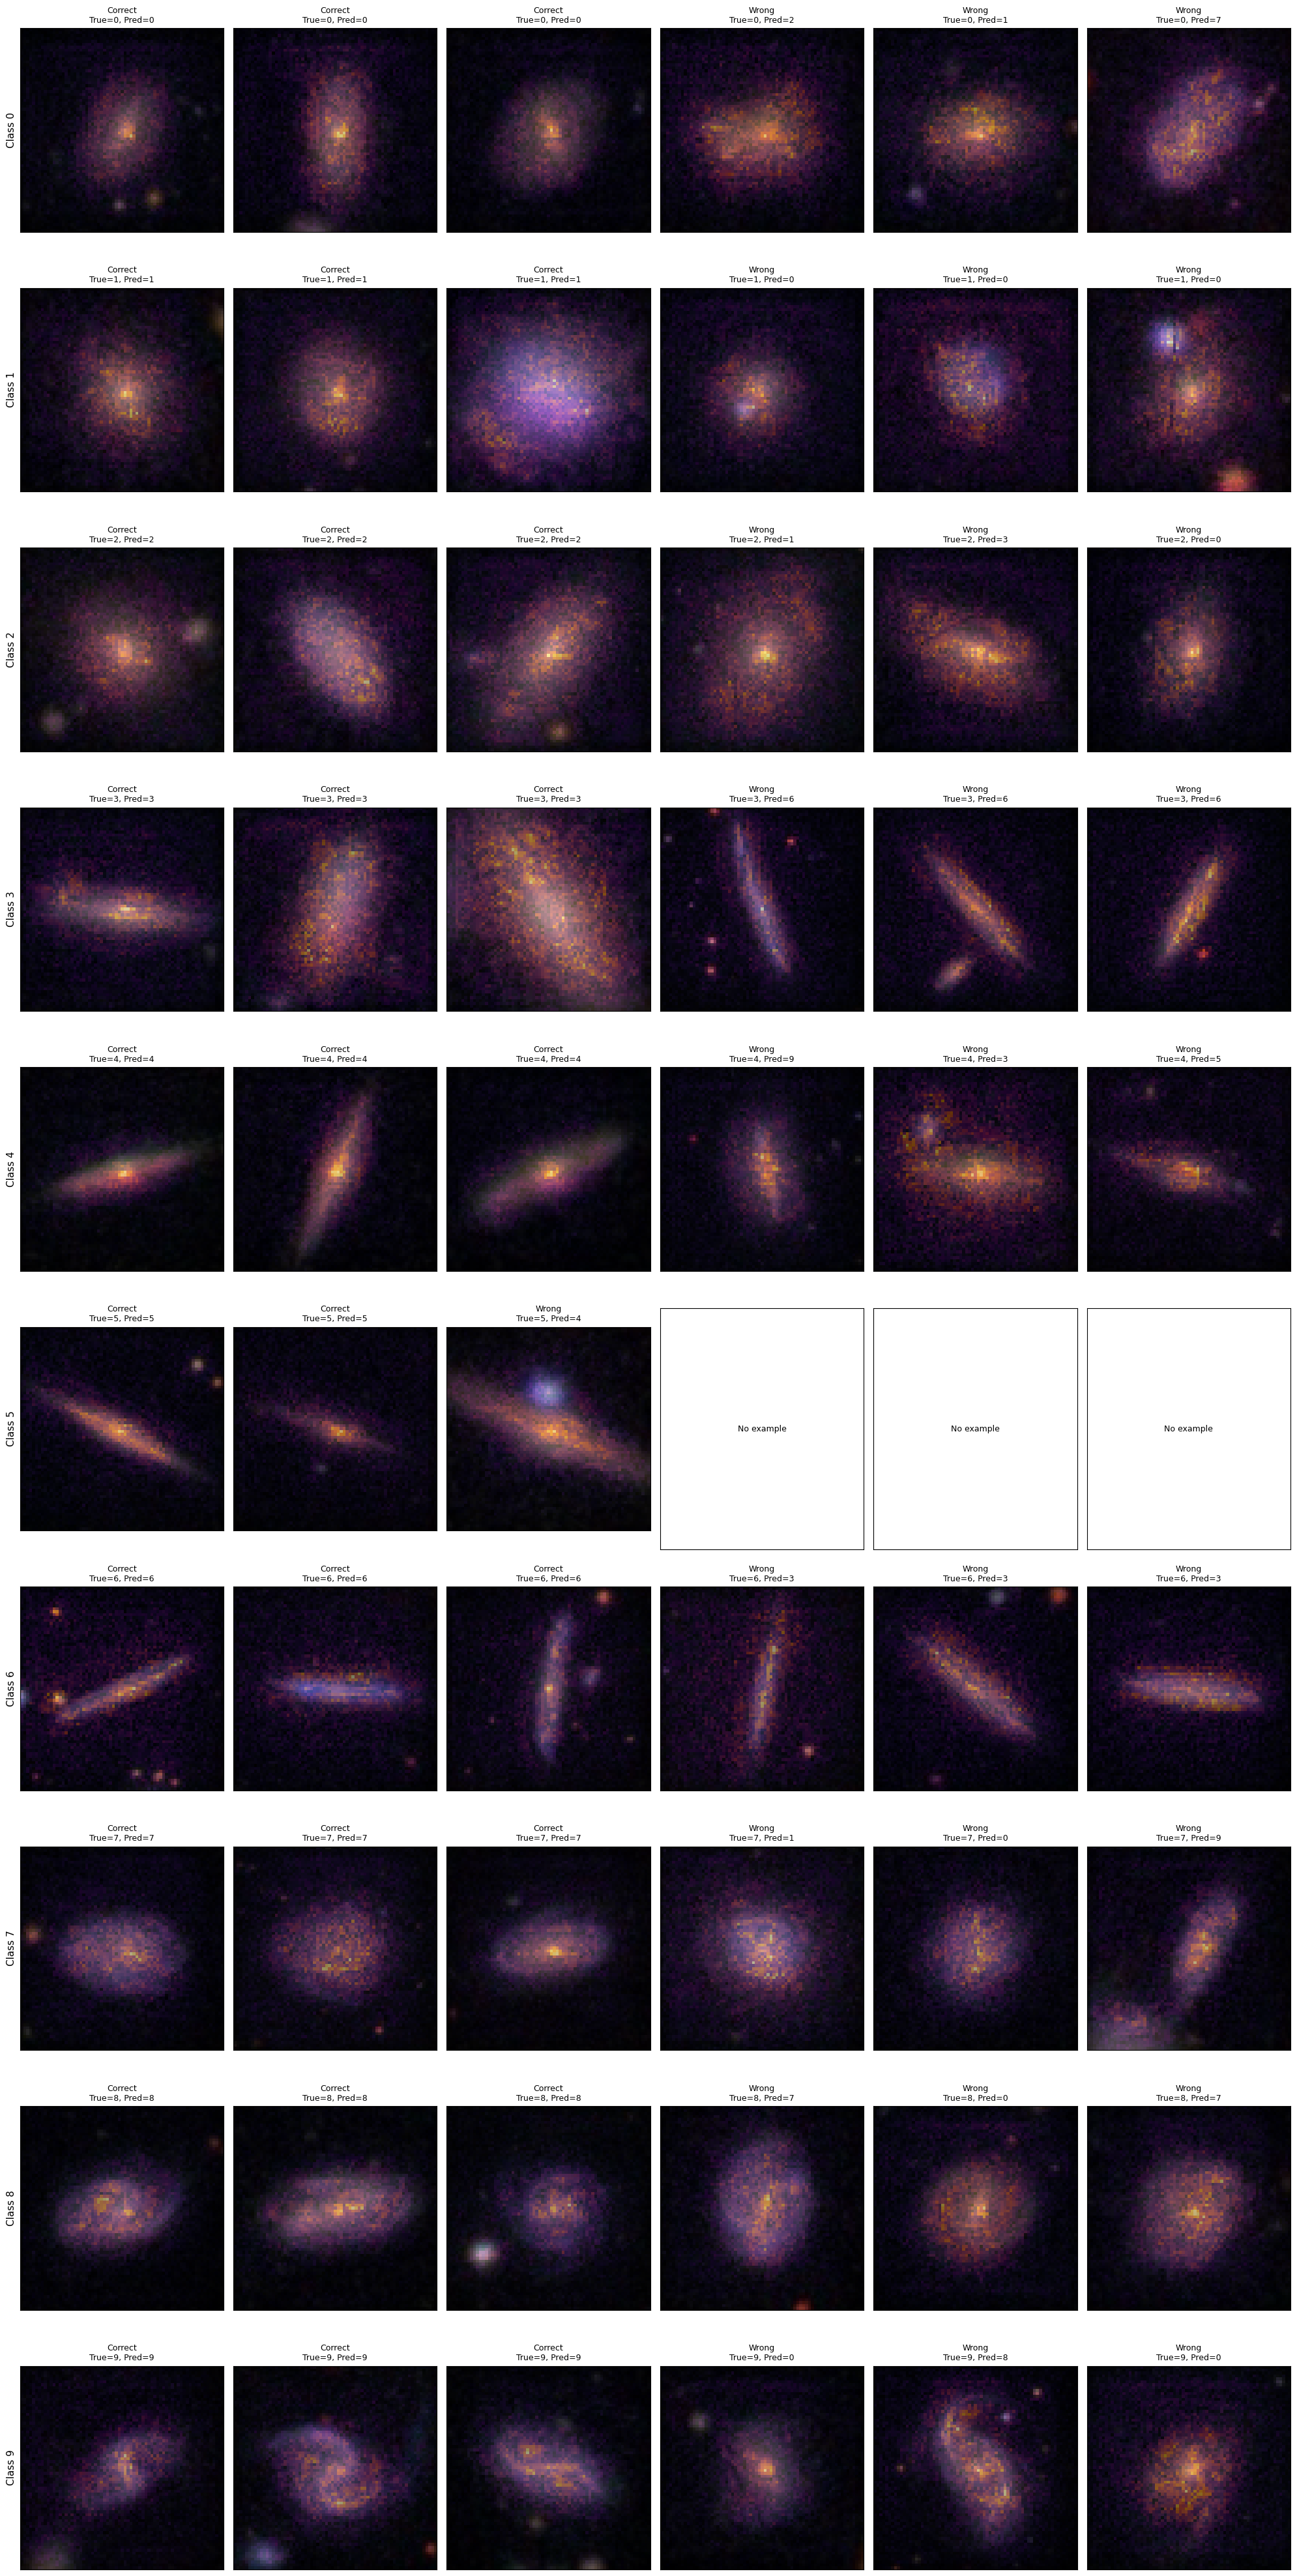

In [49]:
# Standalone saliency gallery (same structure as the Grad-CAM gallery).
ensure_trained_model_loaded()
if "y_pred" not in globals() or "y_pred_prob" not in globals():
    y_pred_prob = cnn_model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

classes_to_analyze = list(range(NUM_CLASSES))
n_correct = 3
n_wrong = 3
n_cols = n_correct + n_wrong

fig, axes = plt.subplots(
    len(classes_to_analyze),
    n_cols,
    figsize=(20, 4 * len(classes_to_analyze))
)

if len(classes_to_analyze) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, cls in enumerate(classes_to_analyze):
    correct_idx, wrong_idx = get_correct_wrong_indices(
        y_test, y_pred, cls, n_correct=n_correct, n_wrong=n_wrong
    )

    selected_indices = list(correct_idx) + list(wrong_idx)
    selected_types = (["Correct"] * len(correct_idx)) + (["Wrong"] * len(wrong_idx))

    for col in range(n_cols):
        ax = axes[row, col]

        if col < len(selected_indices):
            idx = selected_indices[col]
            image = X_test[idx]
            true_class = int(y_test[idx])
            predicted_class = int(y_pred[idx])

            saliency_map, explained_class = compute_saliency_map(
                cnn_model,
                np.expand_dims(image, axis=0),
                predicted_class
            )

            # Show original image with saliency overlay.
            ax.imshow(image)
            ax.imshow(saliency_map, cmap="inferno", alpha=0.4)
            ax.set_title(
                f"{selected_types[col]}\nTrue={true_class}, Pred={predicted_class}",
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, "No example", ha="center", va="center", fontsize=9)
            ax.set_facecolor("white")

        if col == 0:
            ax.set_ylabel(f"Class {cls}", fontsize=11)

        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()

For smooth classes (0-1-2), saliency highlights a compact cluster near the nucleus. The highlighted region is smaller and more central than the Grad-CAM activation, suggesting that at pixel level the most sensitive input features are concentrated in the bright galactic core, while the outer smooth envelope is less locally decisive.

For edge-on classes (4-6), saliency and Grad-CAM largely agree: both methods trace the elongated disk. Saliency tends to produce a thinner, more localised highlight (typically on the bulge or the brightest disk patch), while Grad-CAM covers the full disk extent

For spiral classes (7-8-9), saliency maps remain diffuse. The highlighted pixels are scattered across the disk in a way that is hard to interpret morphologically. This confirms that the model does not rely on a single localised feature to distinguish spiral subtypes, consistent with the broad Grad-CAM patterns for the same classes.

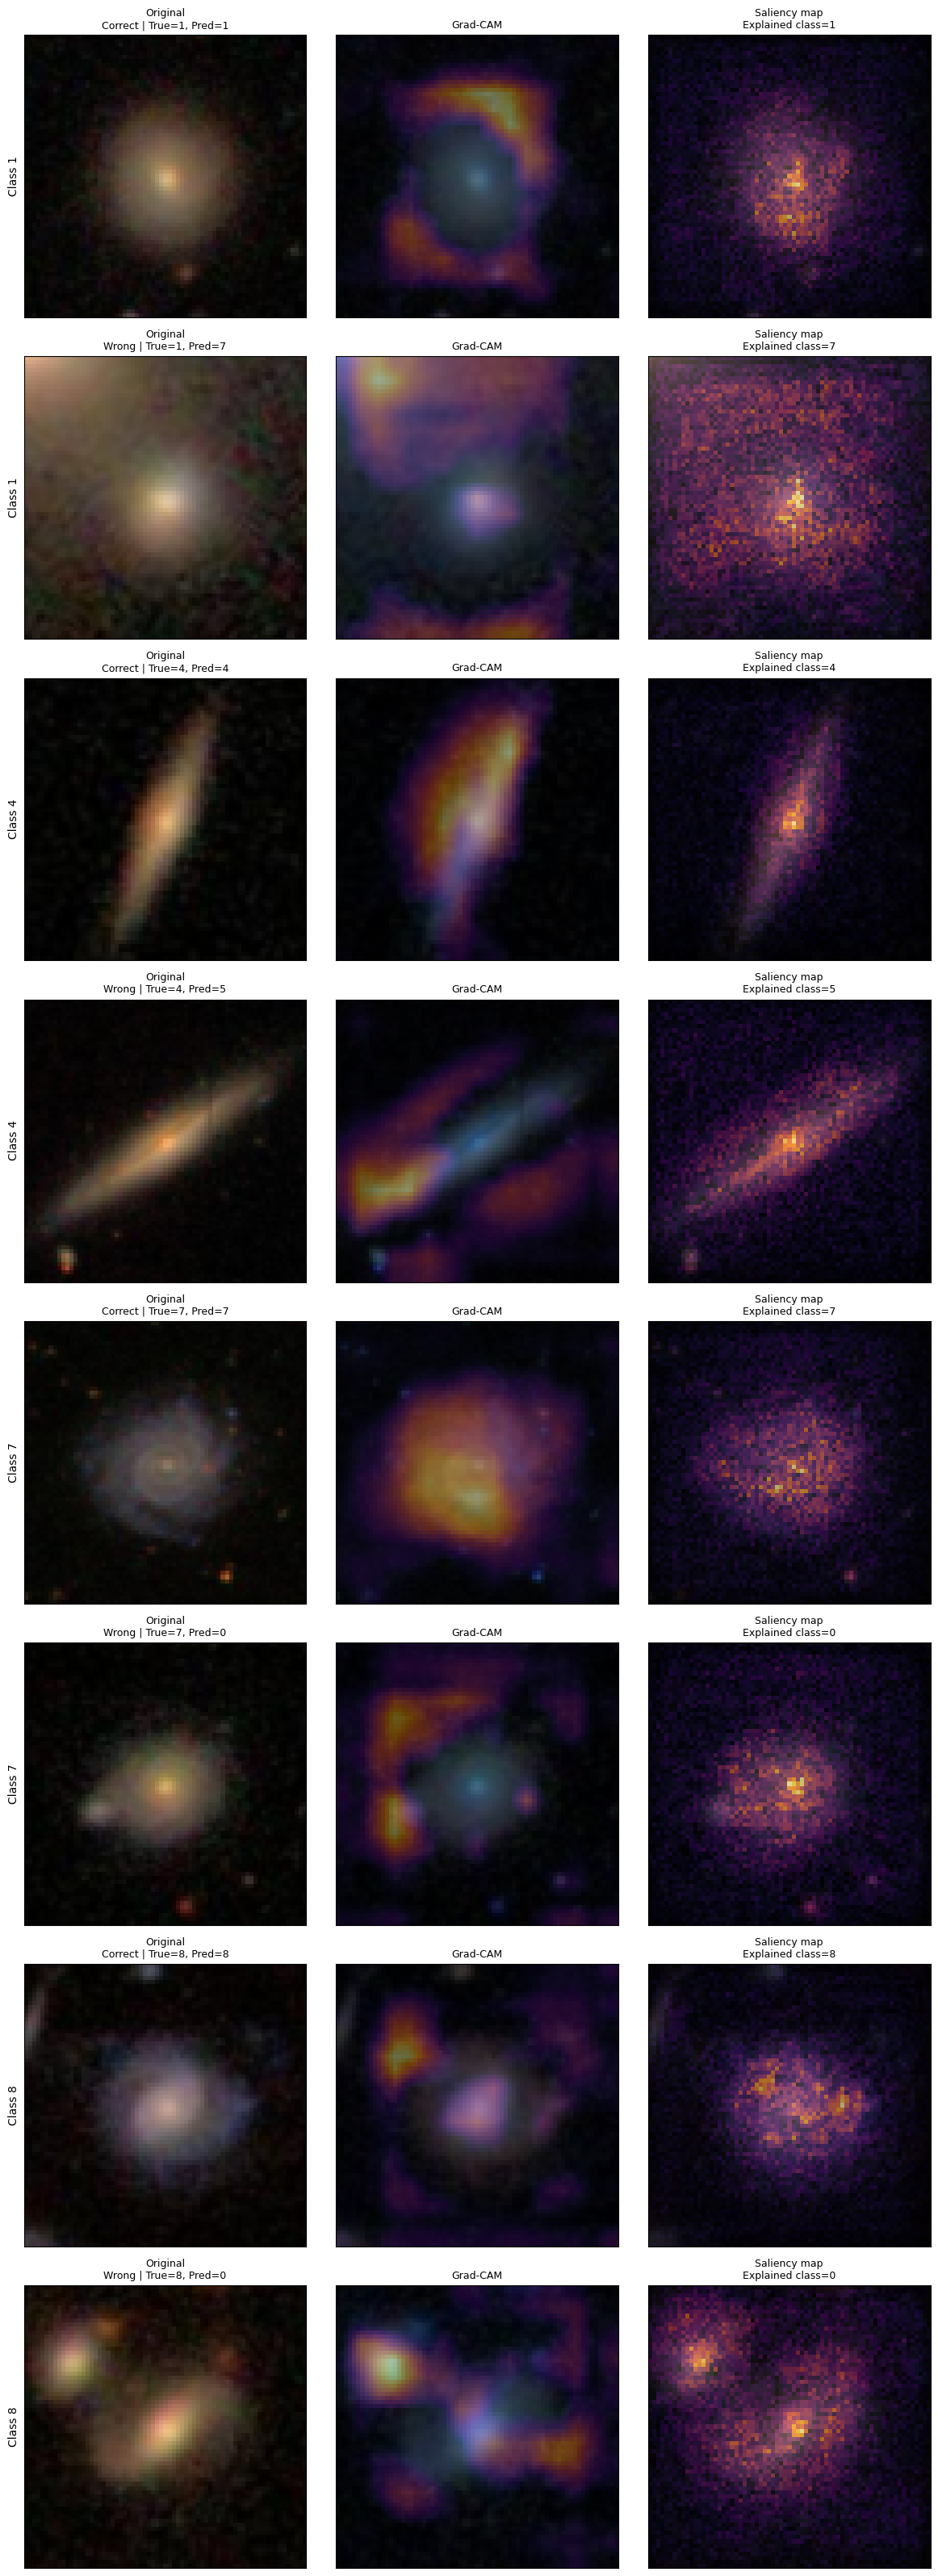

In [ ]:
# Classes chosen to cover: smooth (1), edge-on (4), spiral (7, 8)
# -> the main morphological families in the dataset

comparison_classes = [1, 4, 7, 8]
comparison_examples = []

for cls in comparison_classes:
    correct_idx, wrong_idx = get_correct_wrong_indices(y_test, y_pred, cls, n_correct=1, n_wrong=1)
    if len(correct_idx) > 0:
        comparison_examples.append((cls, int(correct_idx[0]), "Correct"))
    if len(wrong_idx) > 0:
        comparison_examples.append((cls, int(wrong_idx[0]), "Wrong"))

fig, axes = plt.subplots(len(comparison_examples), 3, figsize=(12, 4 * len(comparison_examples)))

if len(comparison_examples) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, (cls, idx, status) in enumerate(comparison_examples):
    image = X_test[idx]
    true_class = int(y_test[idx])
    predicted_class = int(y_pred[idx])
    image_batch = np.expand_dims(image, axis=0)

    gradcam_heatmap = compute_gradcam(cnn_model, image_batch, predicted_class, last_conv_layer)
    gradcam_overlay = overlay_gradcam(image, gradcam_heatmap, alpha=0.4)
    gradcam_overlay = cv2.cvtColor(gradcam_overlay, cv2.COLOR_BGR2RGB)

    saliency_map, saliency_class = compute_saliency_map(cnn_model, image_batch, predicted_class)

    axes[row, 0].imshow(image)
    axes[row, 0].set_title(
        f"Original\n{status} | True={true_class}, Pred={predicted_class}",
        fontsize=9
    )

    axes[row, 1].imshow(gradcam_overlay)
    axes[row, 1].set_title("Grad-CAM", fontsize=9)

    axes[row, 2].imshow(image)
    axes[row, 2].imshow(saliency_map, cmap="inferno", alpha=0.4)
    axes[row, 2].set_title(f"Saliency map\nExplained class={saliency_class}", fontsize=9)

    for col in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

    axes[row, 0].set_ylabel(f"Class {cls}", fontsize=10)

plt.tight_layout()
plt.show()


### Comparison between Grad-CAM and saliency maps

For well-separated, geometrically structured classes (4, 6, 3), both methods agree and produce physically meaningful localizations. For ambiguous or visually similar classes (0/1/2, 7/8/9), neither method provides a clear, stable explanation reflecting the difficulty of the task rather than a failure of the methods themselves. These results suggest the model can be trusted for edge-on morphologies but should be used with caution for spiral galaxies discrimination.

In [ ]:
# TENTATIVE GRAD-CAM CONCENTRATION METRIC: fraction of Grad-CAM mass within a central circle

def gradcam_concentration(heatmap, target_size=(69, 69), radius=25):
    """Fraction of Grad-CAM mass within a central circle
    Resizes heatmap to target_size first (consistent with overlay_gradcam)"""
    heatmap_resized = cv2.resize(heatmap, (target_size[1], target_size[0]))
    h, w = heatmap_resized.shape
    cy, cx = h // 2, w // 2
    y, x = np.ogrid[:h, :w]
    mask = (x - cx)**2 + (y - cy)**2 <= radius**2
    return float(heatmap_resized[mask].sum() / (heatmap_resized.sum() + 1e-8))


all_correct, all_wrong = [], []
for cls in range(NUM_CLASSES):
    c_idx, w_idx = get_correct_wrong_indices(y_test, y_pred, cls, n_correct=5, n_wrong=5)
    all_correct.extend(c_idx.tolist())
    all_wrong.extend(w_idx.tolist())

scores = {'correct': [], 'wrong': []}
for idx in all_correct:
    hm = compute_gradcam(cnn_model, X_test[idx:idx+1], int(y_pred[idx]), last_conv_layer)
    scores['correct'].append(gradcam_concentration(hm))
for idx in all_wrong:
    hm = compute_gradcam(cnn_model, X_test[idx:idx+1], int(y_pred[idx]), last_conv_layer)
    scores['wrong'].append(gradcam_concentration(hm))

print(f"Random baseline (41% of pixels): 0.410")
for k, v in scores.items():
    print(f"{k:8s}: {np.mean(v):.3f} ± {np.std(v):.3f}")

class_names = [
    'Face-on No Spiral', 'Completely Round', 'In-between Round',
    'Cigar-shaped', 'Edge-on Rounded Bulge', 'Edge-on Boxy Bulge',
    'Edge-on No Bulge', 'Tight Spiral', 'Medium Spiral', 'Loose Spiral'
]
print("\nPer-class mean concentration (correct predictions):")
for c in range(NUM_CLASSES):
    c_idx, _ = get_correct_wrong_indices(y_test, y_pred, c, n_correct=15, n_wrong=0)
    if len(c_idx) == 0:
        print(f"Class {c} ({class_names[c]:20s}): no samples")
        continue
    concs = [gradcam_concentration(
        compute_gradcam(cnn_model, X_test[i:i+1], c, last_conv_layer)
    ) for i in c_idx]
    print(f"Class {c} ({class_names[c]:20s}): {np.mean(concs):.3f}")


Random baseline (41% of pixels): 0.410
correct : 0.739 ± 0.150
wrong   : 0.715 ± 0.182

Per-class mean concentration (correct predictions):
Class 0 (Face-on No Spiral   ): 0.638
Class 1 (Completely Round    ): 0.834
Class 2 (In-between Round    ): 0.754
Class 3 (Cigar-shaped        ): 0.768
Class 4 (Edge-on Rounded Bulge): 0.831
Class 5 (Edge-on Boxy Bulge  ): 0.747
Class 6 (Edge-on No Bulge    ): 0.666
Class 7 (Tight Spiral        ): 0.752
Class 8 (Medium Spiral       ): 0.775
Class 9 (Loose Spiral        ): 0.593


---

## Objective 3
## Build an algorithm to efficiently perform an anomaly-detection task by considering some of the classes for training and treating the others as unseen.

The goal is to train an anomaly detector on a specific subset of "known" galaxy classes and then use it to flag samples from "unseen" classes as anomalies during testing.

- **Known classes**: `0, 1, 2`

- **Anomaly classes**: `3, 4, 5, 6, 7, 8, 9` because complex + rarer morphologies

### Feature extraction

I reused the already-trained CNN as a feature extractor from its `dense` layer (256 neurons).
While the Softmax layer is forced to squeeze information into 10 specific categories, the preceding `dense` layer contains a richer, more generic informative representation of galactic structure.
The CNN feature extractor saw all classes during its initial training. However, by training the anomaly detectors (SVM/IF) exclusively on classes 0, 1, and 2, I evaluated the models' ability to define a boundary based strictly on the morphology of the classes 0, 1 and 2.

Features are standardized using `StandardScaler` (zero mean, unit variance) before fitting. This is critical for distance-based and boundary-based methods like One-Class SVM.


### Method 1: One-Class SVM

**One-Class SVM** (Support Vector Machine) (OCSVM) learns a decision boundary (a hypersphere in kernel space) that encloses the region where known galaxies are most concentrated. Points inside the boundary are considered normal (inliers). Points outside are considered anomalies (outliers).

Classical SVM (binary) finds the hyperplane that separates class A and class B with maximum margin. One-class SVM has no class B. It finds a funciotn $f(x)$ that is dense in normal regions (i.e. where known galaxies leave) and negative elsewhere.

The model identifies the optimal boundary by solving the optimization problem:

$$\min_{w,\xi,\rho} \frac{1}{2}\|w\|^2 + \frac{1}{\nu n}\sum_i \xi_i - \rho$$

Subject to:
$$\langle w, \Phi(x_i)\rangle \geq \rho - \xi_i, \quad \xi_i \geq 0$$

- $\|w\|^2$: penalizes the complexity of the model to ensure the boundary is smooth and generalizes well
- $\xi_i$ (Slack variables): allow for some training points to fall outside the boundary
- $\rho$: represents the distance of the boundary from the origin in the feature space
- $\Phi(x_i)$: the kernel function that maps data into a higher-dimensional space to find a non-linear boundary. RBF Kernel (Radial Basis Function): allows the model to map the 256-dimensional features into a higher-dimensional space. It is essential for creating a non-linear boundary that can wrap around the complex distribution of normal galaxies
- $\nu = 0.05$ "regularization" parameter -> 5% margin for error, allowing the model to ignore slight outliers during training. This prevents the boundary from being over-stretched by noise, keeping the "normalcy zone" compact and reliable
- $\gamma = \text{'auto'}$: controls the "reach" of each training sample. With 256 features, the `auto` setting calculates $\gamma \approx 0.0039$ -> ensures a smooth, generalized boundary; a higher gamma would make the model too sensitive to individual points (overfitting), while a lower one would make the boundary too vague (underfitting)

Instead of comparing Class A to Class B, the OCSVM treats the origin of the feature space as the only "anomaly." It attempts to separate all known training points from that origin with the maximum possible margin. Any test sample falling outside this learned "safe zone" is flagged as an anomaly.

The model returns a decision function score:
- score > 0 -> inlier
- score < 0 -> outlier


### Method 2 — Isolation Forest 

The **Isolation Forest** detects anomalies through random partitioning. It builds an ensemble of isolation trees. Each tree randomly selects a feature and a split value, recursively partitioning the data. Anomalies are isolated faster(closer to the root of the tree) because they lie in sparse regions of feature space.

The anomaly score for a sample $x$ is: $s(x, n) = 2^{-\frac{E[h(x)]}{c(n)}}$

where $h(x)$ is the path length from root to leaf, $E[h(x)]$ is its average over all trees, and $c(n)$ is the expected path length for a dataset of size $n$ (normalization constant). A score near 1 means strongly anomalous; near 0.5 is ambiguous; near 0 is a dense inlier.

### Evaluation metrics

**Binary detection task** (known vs anomaly) -> the following metrics are used:

| Metric | Formula | Interpretation |
|--------|---------|----------------|
| **Sensitivity** (Recall on known) | $\frac{TP}{TP + FN}$ | Fraction of known galaxies correctly identified as known — low means the detector is over-triggering on normal data |
| **Specificity** (Recall on anomalies) | $\frac{TN}{TN + FP}$ | Fraction of anomalous galaxies correctly identified as anomalies — low means unseen classes are leaking through |
| **ROC-AUC** | Area under the ROC curve | Threshold-free overall discrimination ability: 0.5 = random, 1.0 = perfect separation |

The **ROC curve** plots the True Positive Rate (sensitivity) against the False Positive Rate ($1 -$ specificity) as the decision threshold is swept. The **AUC** summarizes this curve into a single scalar. It is the preferred metric here because:
- It does not require choosing a threshold
- It is interpretable as the probability that the model ranks a known sample higher than an anomaly
- It is robust to class imbalance between known and anomaly test samples

The confusion matrix reports absolute counts of True Negatives (anomalies caught), False Positives (anomalies missed), False Negatives (known samples flagged), and True Positives (known samples correctly passed).


In [55]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, auc

""""
# Extract features: use model predictions as features (high-dimensional probability representation)
# This captures the learned feature space for each image through the network
print("Extracting features using model predictions...")
ensure_trained_model_loaded()


X_train_features = cnn_model.predict(X_train, verbose=0)
X_val_features = cnn_model.predict(X_val, verbose=0)
X_test_features = cnn_model.predict(X_test, verbose=0)

print(f"Extracted feature shape: {X_train_features.shape}")
print(f"Features are class probabilities encoding morphological information")
"""


feature_extractor = tf.keras.Model(
    inputs=cnn_model.layers[0].input, 
    outputs=cnn_model.get_layer('dense').output
)

X_train_features = feature_extractor.predict(X_train, verbose=0)
X_val_features = feature_extractor.predict(X_val, verbose=0)
X_test_features = feature_extractor.predict(X_test, verbose=0)

print(f"Features estratte dallo spazio latente (Dense layer): {X_train_features.shape}")

Features estratte dallo spazio latente (Dense layer): (15249, 256)


In [56]:
# Define known and anomaly classes
KNOWN_CLASSES = [0, 1, 2]  # Classes used for training
ANOMALY_CLASSES = [3, 4, 5, 6, 7, 8, 9]

# Create binary labels: 1 for known (normal), -1 for anomaly
train_anomaly_mask = np.isin(y_train, KNOWN_CLASSES)
test_anomaly_mask = np.isin(y_test, KNOWN_CLASSES)

print(f"Known classes: {KNOWN_CLASSES}")
print(f"Anomaly classes: {ANOMALY_CLASSES}")
print(f"Training samples - Known: {np.sum(train_anomaly_mask)}, Anomaly: {np.sum(~train_anomaly_mask)}")
print(f"Test samples - Known: {np.sum(test_anomaly_mask)}, Anomaly: {np.sum(~test_anomaly_mask)}")

# Standardize features
scaler = StandardScaler()
X_train_features_scaled = scaler.fit_transform(X_train_features)
X_test_features_scaled = scaler.transform(X_test_features)

# Train One-Class SVM on known classes only
known_train_idx = np.isin(y_train, KNOWN_CLASSES)
X_known_train = X_train_features_scaled[known_train_idx]

oc_svm = OneClassSVM(gamma='auto', nu=0.05)  # nu: approximate fraction of anomalies
oc_svm.fit(X_known_train)

# Predictions: 1 = inlier (known), -1 = outlier (anomaly)
y_pred_ood = oc_svm.predict(X_test_features_scaled)

# Decision scores for ROC-AUC
y_scores_ood = oc_svm.decision_function(X_test_features_scaled)

# Convert boolean mask to binary labels: 1 (known/normal), 0 (anomaly)
y_true_ood = test_anomaly_mask.astype(int)

print(f"\n✓ One-Class SVM trained on {len(X_known_train)} known galaxy images")


Known classes: [0, 1, 2]
Anomaly classes: [3, 4, 5, 6, 7, 8, 9]
Training samples - Known: 11725, Anomaly: 3524
Test samples - Known: 2513, Anomaly: 755



✓ One-Class SVM trained on 11725 known galaxy images


ANOMALY DETECTION RESULTS (One-Class SVM)

ROC-AUC Score (OOD Detection): 0.9393

Confusion Matrix:
  TN:   575 (Anomalies correctly detected as anomalies)
  FP:   180 (Anomalies incorrectly marked as known)
  FN:   123 (Known incorrectly marked as anomalies)
  TP:  2390 (Known correctly identified)

Recall - Known galaxies detected: 0.9511 (2390/2513)
Recall - Anomalies detected:      0.7616 (575/755)

Sensitivity (True Positive Rate): 0.9511
Specificity (True Negative Rate): 0.7616


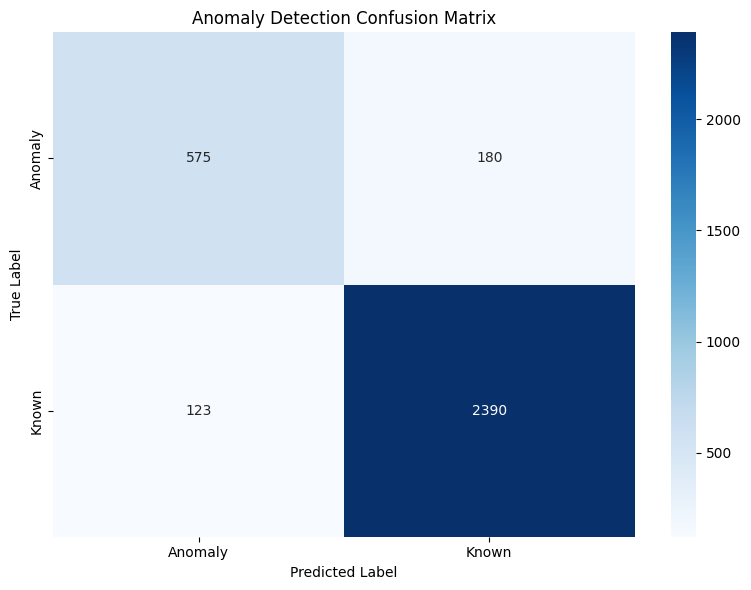

In [57]:
# Evaluate anomaly detection
from sklearn.metrics import (
    confusion_matrix, classification_report, 
    roc_auc_score, roc_curve, precision_recall_curve
)

# Convert OOD predictions: -1 → 0 (anomaly), 1 → 1 (known)
y_pred_ood_binary = (y_pred_ood == 1).astype(int)

# Evaluate
auc_score = roc_auc_score(y_true_ood, y_scores_ood)
cm_ood = confusion_matrix(y_true_ood, y_pred_ood_binary)

# Classification metrics
correct = np.sum(y_pred_ood_binary[y_true_ood == 1])
known_total = np.sum(y_true_ood == 1)
recall_known = correct / known_total if known_total > 0 else 0

correct_anom = np.sum((y_pred_ood_binary == 0)[y_true_ood == 0])
anom_total = np.sum(y_true_ood == 0)
recall_anomaly = correct_anom / anom_total if anom_total > 0 else 0

print("=" * 60)
print("ANOMALY DETECTION RESULTS (One-Class SVM)")
print("=" * 60)
print(f"\nROC-AUC Score (OOD Detection): {auc_score:.4f}")
print(f"\nConfusion Matrix:")
print(f"  TN: {cm_ood[0,0]:5d} (Anomalies correctly detected as anomalies)")
print(f"  FP: {cm_ood[0,1]:5d} (Anomalies incorrectly marked as known)")
print(f"  FN: {cm_ood[1,0]:5d} (Known incorrectly marked as anomalies)")
print(f"  TP: {cm_ood[1,1]:5d} (Known correctly identified)")

print(f"\nRecall - Known galaxies detected: {recall_known:.4f} ({correct}/{known_total})")
print(f"Recall - Anomalies detected:      {recall_anomaly:.4f} ({correct_anom}/{anom_total})")

tn, fp, fn, tp = cm_ood[0,0], cm_ood[0,1], cm_ood[1,0], cm_ood[1,1]
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
print(f"\nSensitivity (True Positive Rate): {sensitivity:.4f}")
print(f"Specificity (True Negative Rate): {specificity:.4f}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_ood, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Anomaly', 'Known'],
            yticklabels=['Anomaly', 'Known'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Anomaly Detection Confusion Matrix')
plt.tight_layout()
plt.show()



ANOMALY DETECTION RESULTS (Isolation Forest)
ROC-AUC Score: 0.9691

Confusion Matrix:
  TN:   682
  FP:    73
  FN:   212
  TP:  2301


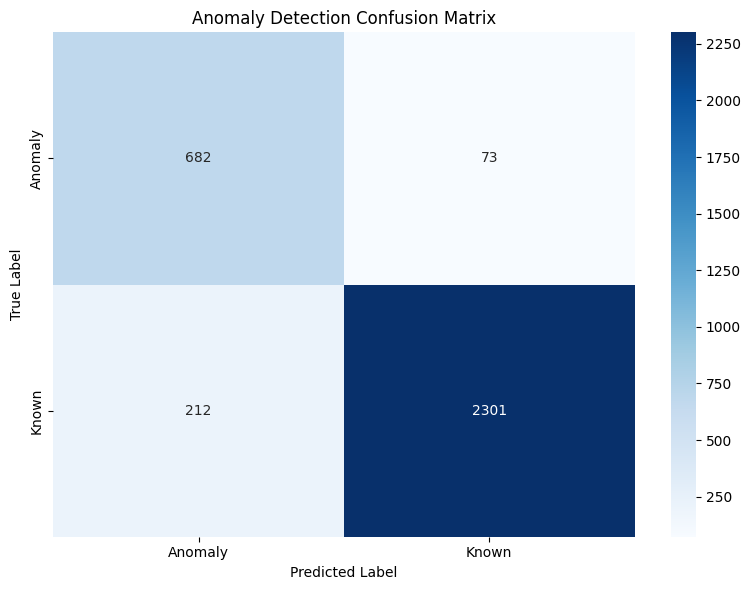

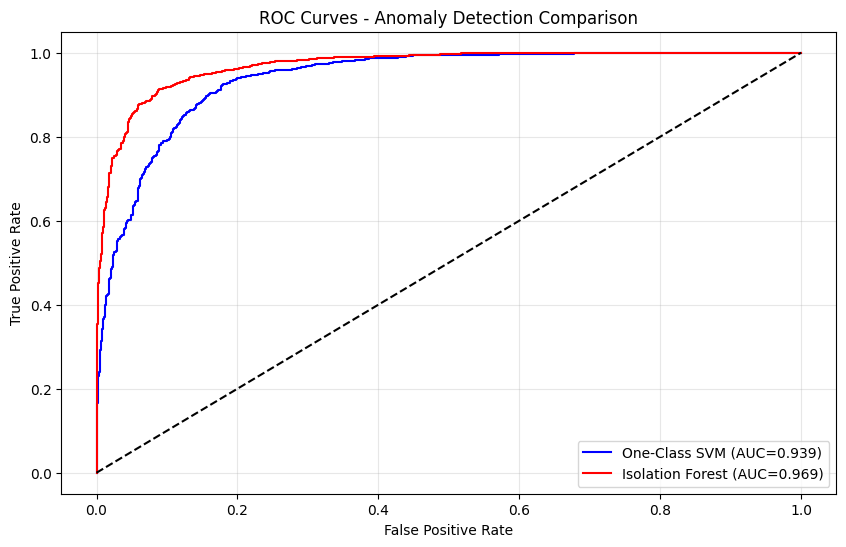


✓ Anomaly Detection complete: compare the updated AUC values after rerunning this cell


In [ ]:
# Alternative: Isolation Forest for anomaly detection
iso_forest = IsolationForest(contamination='auto', random_state=SEED)
iso_forest.fit(X_known_train)

# Predictions: -1 = anomaly, 1 = inlier
y_pred_iso = iso_forest.predict(X_test_features_scaled)
y_scores_iso = iso_forest.score_samples(X_test_features_scaled)

# Convert binary labels
y_pred_iso_binary = (y_pred_iso == 1).astype(int)

# Evaluate
auc_iso = roc_auc_score(y_true_ood, y_scores_iso)  # Higher score = more normal/inlier, matching y_true_ood=1 for known

print("\n" + "=" * 60)
print("ANOMALY DETECTION RESULTS (Isolation Forest)")
print("=" * 60)
print(f"ROC-AUC Score: {auc_iso:.4f}")

cm_iso = confusion_matrix(y_true_ood, y_pred_iso_binary)
print(f"\nConfusion Matrix:")
print(f"  TN: {cm_iso[0,0]:5d}")
print(f"  FP: {cm_iso[0,1]:5d}")
print(f"  FN: {cm_iso[1,0]:5d}")
print(f"  TP: {cm_iso[1,1]:5d}")

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Anomaly', 'Known'],
            yticklabels=['Anomaly', 'Known'])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.title('Anomaly Detection Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC curves comparison
fpr_iso, tpr_iso, _ = roc_curve(y_true_ood, y_scores_iso)
fpr_svm, tpr_svm, _ = roc_curve(y_true_ood, y_scores_ood)

plt.figure(figsize=(10, 6))
plt.plot(fpr_svm, tpr_svm, 'b-', label=f'One-Class SVM (AUC={auc_score:.3f})')
plt.plot(fpr_iso, tpr_iso, 'r-', label=f'Isolation Forest (AUC={auc_iso:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Anomaly Detection Comparison')
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

print(f"\n✓ Anomaly Detection complete: compare the updated AUC values after rerunning this cell")
